# Compulsory Assignment 2 - Machine Learning and Deep Learning (CDSCO2041C)

**Student IDs:** 185912, 161989, 160714 & 160363

**Course:** Machine Learning and Deep Learning (CDSCO2041C)  
**Instructor:** Somnath Mazumdar, Department of Digitalization, CBS

## Setup and Imports

In [10]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM 

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              IsolationForest)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_squared_error, r2_score,
                             silhouette_score)

# Settings
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

tscv = TimeSeriesSplit(n_splits=5)

Imports all libraries we need. `pandas`/`numpy` for data, `matplotlib`/`seaborn` for plots, `hmmlearn` for regime detection, and various `sklearn` modules for preprocessing, models, and evaluation. `TimeSeriesSplit` is used instead of regular k-fold CV to respect the time ordering of our data. `tscv` is a global CV splitter reused throughout.

## Data Loading and Cleaning

**Data files:**
- `_eth_dkk.csv` - Ethereum prices in DKK (semicolon-delimited, Danish headers, ~366 daily rows, Mar 2025 - Mar 2026)
- `_XCSE_NOVO-1.csv` - Novo Nordisk stock prices (comma-delimited, ~250 trading-day rows, Feb 2025 - Feb 2026, prices have leading dots e.g. ".238.00")

In [11]:
# ETH // DKK
df_eth = pd.read_csv('Data/_eth_dkk.csv', sep=';', quotechar='"')

# Rename Danish headers to English
df_eth.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Market_Cap', 'Change_Pct']

# Parse dates and sort
df_eth['Date'] = pd.to_datetime(df_eth['Date'])
df_eth = df_eth.sort_values('Date').reset_index(drop=True)

# Convert OHLC and Change_Pct to float
for col in ['Open', 'High', 'Low', 'Close', 'Change_Pct']:
    df_eth[col] = df_eth[col].astype(str).str.replace('+', '', regex=False).astype(float)

# Parse Volume and Market_Cap (e.g. "132.89B" -> 132.89e9)
def parse_suffix(val):
    val = str(val).strip()
    if val.endswith('T'):
        return float(val[:-1]) * 1e12
    elif val.endswith('B'):
        return float(val[:-1]) * 1e9
    elif val.endswith('M'):
        return float(val[:-1]) * 1e6
    return float(val)

df_eth['Volume'] = df_eth['Volume'].apply(parse_suffix)
df_eth['Market_Cap'] = df_eth['Market_Cap'].apply(parse_suffix)

df_eth = df_eth.set_index('Date')

print(f"Shape: {df_eth.shape} | Range: {df_eth.index.min().date()} to {df_eth.index.max().date()}")
print(f"NaN: {df_eth.isna().sum().sum()}")
df_eth.head()

Shape: (366, 7) | Range: 2025-03-01 to 2026-03-01
NaN: 0


,Open,High,Low,Close,Volume,Market_Cap,Change_Pct
Date,,,,,,,
2025-03-01,16081.11,16394.10,15399.37,15935.94,1.328900e+11,1.920000e+12,-0.99
2025-03-02,15936.01,18330.51,15610.02,18097.15,1.115400e+11,2.180000e+12,13.56
2025-03-03,17932.04,17970.78,14939.64,15303.53,2.945900e+11,1.850000e+12,-15.44
2025-03-04,15122.44,15635.15,14025.95,15280.70,2.440500e+11,1.840000e+12,-0.15
2025-03-05,15010.06,15715.18,14896.21,15494.54,1.854100e+11,1.870000e+12,1.40


Loads ETH/DKK data from a semicolon-delimited CSV with Danish headers. Renames columns to English, parses dates, converts price strings to floats, and handles Volume/Market_Cap suffixes (e.g. "132.89B" → 132.89 billion). Sets Date as index.

In [12]:
# novo nordisk
df_novo = pd.read_csv('Data/_XCSE_NOVO-1.csv')

# Parse dates and sort
df_novo['Date'] = pd.to_datetime(df_novo['Date'], format='%m/%d/%Y')
df_novo = df_novo.sort_values('Date').reset_index(drop=True)

# Clean OHLC: remove leading dot (e.g. ".238.00" -> "238.00")
for col in ['Open', 'High', 'Low', 'Close']:
    df_novo[col] = df_novo[col].astype(str).str.strip('"').str.lstrip('.').astype(float)

# Clean Volume: remove commas
df_novo['Volume'] = df_novo['Volume'].astype(str).str.strip('"').str.replace(',', '', regex=False).astype(int)

df_novo = df_novo.set_index('Date')

print(f"Shape: {df_novo.shape} | Range: {df_novo.index.min().date()} to {df_novo.index.max().date()}")
print(f"NaN: {df_novo.isna().sum().sum()}")
df_novo.head()

Shape: (250, 5) | Range: 2025-02-27 to 2026-02-27
NaN: 0


,Open,High,Low,Close,Volume
Date,,,,,
2025-02-27,630.0,645.8,628.3,641.8,2974061
2025-02-28,641.0,648.2,631.2,644.5,7285161
2025-03-03,650.0,651.2,636.2,639.1,2242871
2025-03-04,634.6,642.4,616.2,616.2,3058878
2025-03-05,616.1,649.4,614.0,631.5,3515981


Loads Novo Nordisk stock data. Cleans prices by stripping leading dots (e.g. ".238.00" → 238.00) and removes commas from volume. Only has weekday trading data (250 days).

In [13]:
# --- Combined DataFrame ---
# Reindex Novo to full daily range, forward-fill weekends/holidays with Friday's price
full_range = pd.date_range(
    start=min(df_eth.index.min(), df_novo.index.min()),
    end=max(df_eth.index.max(), df_novo.index.max()),
    freq='D'
)
df_novo_daily = df_novo.reindex(full_range).ffill()
df_novo_daily.index.name = 'Date'

# Inner join on overlapping dates
df_combined = df_eth.join(df_novo_daily, how='inner', lsuffix='_eth', rsuffix='_novo')

print(f"Shape: {df_combined.shape} | Range: {df_combined.index.min().date()} to {df_combined.index.max().date()}")
print(f"NaN: {df_combined.isna().sum().sum()}")
df_combined.head()

Shape: (366, 12) | Range: 2025-03-01 to 2026-03-01
NaN: 0


,Open_eth,High_eth,Low_eth,Close_eth,Volume_eth,Market_Cap,Change_Pct,Open_novo,High_novo,Low_novo,Close_novo,Volume_novo
Date,,,,,,,,,,,,
2025-03-01,16081.11,16394.10,15399.37,15935.94,1.328900e+11,1.920000e+12,-0.99,641.0,648.2,631.2,644.5,7285161.0
2025-03-02,15936.01,18330.51,15610.02,18097.15,1.115400e+11,2.180000e+12,13.56,641.0,648.2,631.2,644.5,7285161.0
2025-03-03,17932.04,17970.78,14939.64,15303.53,2.945900e+11,1.850000e+12,-15.44,650.0,651.2,636.2,639.1,2242871.0
2025-03-04,15122.44,15635.15,14025.95,15280.70,2.440500e+11,1.840000e+12,-0.15,634.6,642.4,616.2,616.2,3058878.0
2025-03-05,15010.06,15715.18,14896.21,15494.54,1.854100e+11,1.870000e+12,1.40,616.1,649.4,614.0,631.5,3515981.0


Creates a combined DataFrame by forward-filling Novo's missing weekend/holiday prices (Friday's price carries to Sat/Sun), then inner-joining with ETH on date. This gives us aligned daily data for both assets. Used for RQ1 comparisons; RQ2 models use separate DataFrames to avoid forward-fill artifacts.

---

## RQ1: Asset Selection

**Should you invest in cryptocurrency (Ethereum) or in equity (Novo Nordisk stock)?**

Using Return on Investment (RoI) as the primary performance metric, compare the two assets. Capital: DKK 250,000.

**Approach:**
- Compute and compare RoI over the full period for both assets
- Analyze risk-adjusted returns (volatility, Sharpe ratio)
- Use market regime identification (e.g., HMM) to distinguish low-volatility vs. high-volatility periods
- Apply anomaly detection to identify extreme events (crashes, spikes)
- Estimate crash-regime probabilities using probabilistic models

### 1.1 RoI Comparison

In [14]:
CAPITAL = 250_000

# Daily returns
df_combined['Return_eth'] = df_combined['Close_eth'].pct_change()
df_combined['Return_novo'] = df_combined['Close_novo'].pct_change()

# Cumulative returns
df_combined['Cum_Return_eth'] = (1 + df_combined['Return_eth']).cumprod() - 1
df_combined['Cum_Return_novo'] = (1 + df_combined['Return_novo']).cumprod() - 1

# Final RoI
roi_eth = df_combined['Cum_Return_eth'].iloc[-1]
roi_novo = df_combined['Cum_Return_novo'].iloc[-1]

final_eth = CAPITAL * (1 + roi_eth)
final_novo = CAPITAL * (1 + roi_novo)

print(f"{'':20} {'ETH/DKK':>12} {'Novo Nordisk':>12}")
print(f"{'Total Return':20} {roi_eth:>11.2%} {roi_novo:>11.2%}")
print(f"{'Final Value (DKK)':20} {final_eth:>12,.0f} {final_novo:>12,.0f}")
print(f"{'Profit/Loss (DKK)':20} {final_eth - CAPITAL:>+12,.0f} {final_novo - CAPITAL:>+12,.0f}")

                          ETH/DKK Novo Nordisk
Total Return             -22.70%     -63.09%
Final Value (DKK)         193,259       92,281
Profit/Loss (DKK)         -56,741     -157,719


Computes daily returns via `pct_change()`, then cumulative returns by compounding. Applies the 250k capital to get final portfolio values. This is the raw RoI comparison.

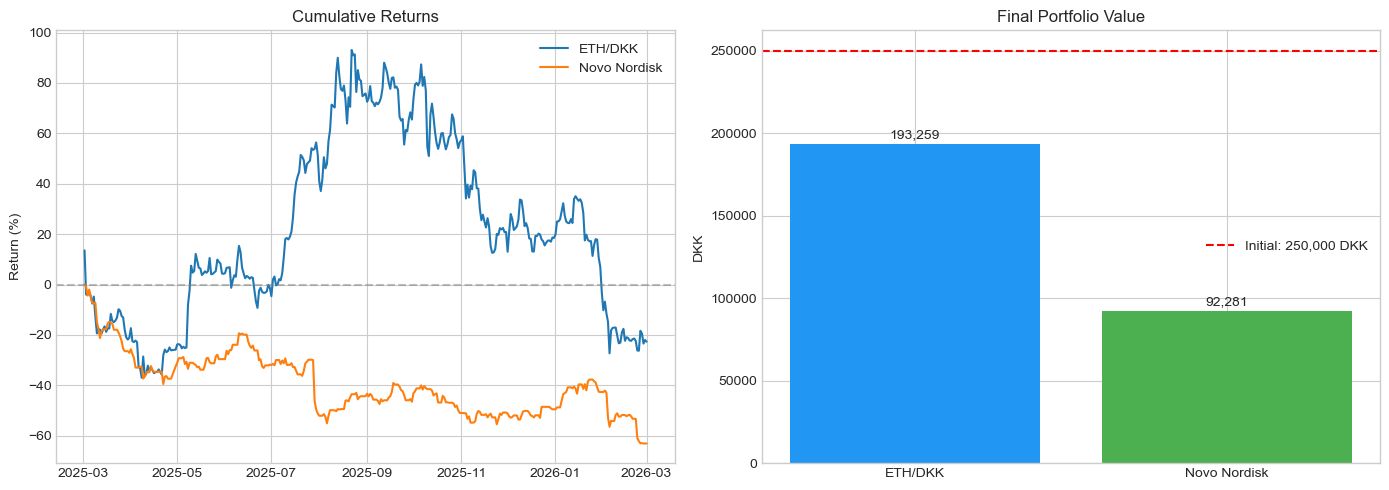

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative returns line plot
axes[0].plot(df_combined.index, df_combined['Cum_Return_eth'] * 100, label='ETH/DKK')
axes[0].plot(df_combined.index, df_combined['Cum_Return_novo'] * 100, label='Novo Nordisk')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Cumulative Returns')
axes[0].set_ylabel('Return (%)')
axes[0].legend()

# Final portfolio value bar chart
assets = ['ETH/DKK', 'Novo Nordisk']
values = [final_eth, final_novo]
colors = ['#2196F3', '#4CAF50']
bars = axes[1].bar(assets, values, color=colors)
axes[1].axhline(y=CAPITAL, color='red', linestyle='--', label=f'Initial: {CAPITAL:,.0f} DKK')
axes[1].set_title('Final Portfolio Value')
axes[1].set_ylabel('DKK')
axes[1].legend()
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Left plot: cumulative return curves over time. Right plot: final portfolio values as bars vs the 250k starting line.

### 1.2 Risk-Adjusted Returns

In [16]:
# Note: Novo volatility is computed from trading-day returns only (df_novo, 252 days/year)
# to avoid deflation from forward-filled 0% weekend returns in df_combined.
# ETH trades 365 days/year so we use df_combined directly.

# Daily returns (drop NaN first row)
eth_returns = df_combined['Return_eth'].dropna()
novo_returns = df_novo['Close'].pct_change().dropna()

# Daily volatility
daily_vol_eth = eth_returns.std()
daily_vol_novo = novo_returns.std()

# Annualized volatility
ann_vol_eth = daily_vol_eth * np.sqrt(365)
ann_vol_novo = daily_vol_novo * np.sqrt(252)

# Annualized returns
n_days_eth = (df_combined.index[-1] - df_combined.index[0]).days
ann_return_eth = (1 + roi_eth) ** (365 / n_days_eth) - 1

n_days_novo = (df_novo.index[-1] - df_novo.index[0]).days
total_return_novo = df_novo['Close'].iloc[-1] / df_novo['Close'].iloc[0] - 1
ann_return_novo = (1 + total_return_novo) ** (365 / n_days_novo) - 1

# Sharpe ratio (risk-free rate = 3%)
rf = 0.03
sharpe_eth = (ann_return_eth - rf) / ann_vol_eth
sharpe_novo = (ann_return_novo - rf) / ann_vol_novo

print(f"{'':25} {'ETH/DKK':>12} {'Novo Nordisk':>12}")
print(f"{'Daily Volatility':25} {daily_vol_eth:>12.4f} {daily_vol_novo:>12.4f}")
print(f"{'Annualized Volatility':25} {ann_vol_eth:>11.2%} {ann_vol_novo:>11.2%}")
print(f"{'Annualized Return':25} {ann_return_eth:>11.2%} {ann_return_novo:>11.2%}")
print(f"{'Sharpe Ratio (rf=3%)':25} {sharpe_eth:>12.3f} {sharpe_novo:>12.3f}")

                               ETH/DKK Novo Nordisk
Daily Volatility                0.0409       0.0354
Annualized Volatility          78.08%      56.25%
Annualized Return             -22.70%     -62.93%
Sharpe Ratio (rf=3%)            -0.329       -1.172


Computes daily and annualized volatility, annualized returns, and Sharpe ratio (risk-free rate = 3%). Novo's volatility uses `df_novo` directly (trading days only, annualized with √252) to avoid deflation from forward-filled 0% weekend returns. ETH uses √365 since it trades every day.

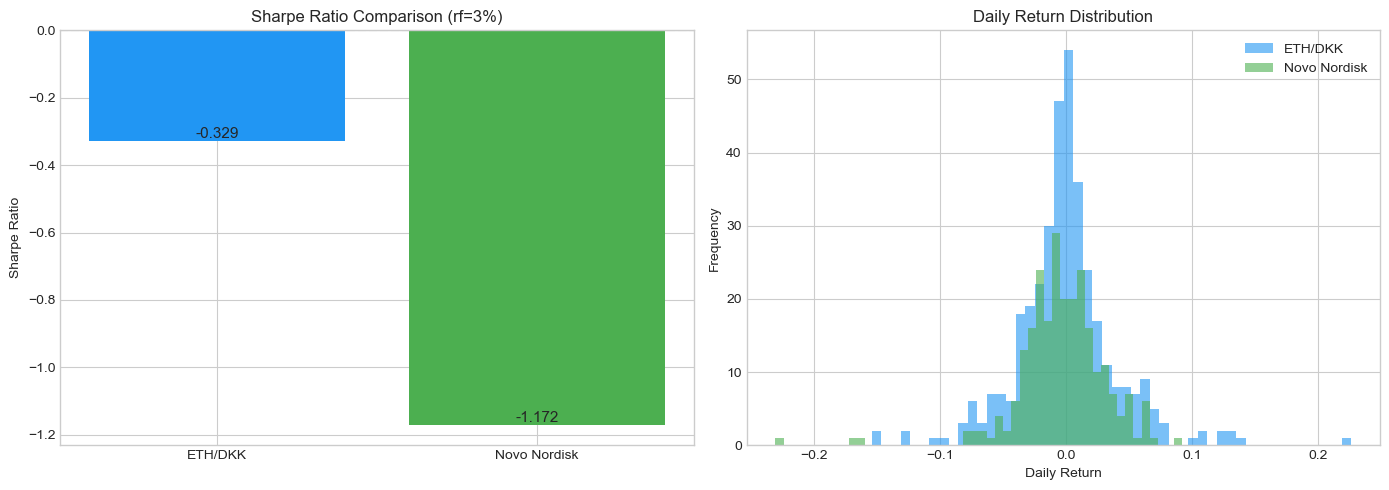

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe ratio comparison
assets = ['ETH/DKK', 'Novo Nordisk']
sharpes = [sharpe_eth, sharpe_novo]
colors = ['#2196F3', '#4CAF50']
bars = axes[0].bar(assets, sharpes, color=colors)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Sharpe Ratio Comparison (rf=3%)')
axes[0].set_ylabel('Sharpe Ratio')
for bar, val in zip(bars, sharpes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)

# Return distribution
axes[1].hist(eth_returns, bins=50, alpha=0.6, label='ETH/DKK', color='#2196F3')
axes[1].hist(novo_returns, bins=50, alpha=0.6, label='Novo Nordisk', color='#4CAF50')
axes[1].set_title('Daily Return Distribution')
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

Left: Sharpe ratio bar comparison. Right: histogram of daily return distributions overlaid, showing how spread out each asset's returns are.

# Evaluation of analysis
Both assets lost money, but ETH was the better pick. Despite higher daily volatility (78% vs 56%), ETH only lost 23% annualized compared to Novo's 63%. The Sharpe ratios reflect this: ETH at -0.33 vs Novo at -1.17. Higher risk on paper, better outcome in practice.

### 1.3 Market Regime Detection

We fit a Gaussian Hidden Markov Model (HMM) per asset using two features: daily returns and 30-day rolling volatility. The HMM assumes the market is always in one of N hidden states, each with its own return distribution. It learns what each state looks like, how likely transitions between states are, and which state each day belongs to.

We test 2, 3, and 4 states and select the best using BIC (Bayesian Information Criterion), which balances model fit against complexity.

In [18]:
def fit_regime_hmm(returns, asset_name, random_state=42):
    """Fit HMM on daily returns + 30-day rolling volatility, compare 2-4 states."""
    
    # Features: daily returns + 30-day rolling volatility
    rolling_vol = returns.rolling(30).std()
    
    features = pd.DataFrame({
        'return': returns,
        'rolling_vol_30': rolling_vol
    }).dropna()
    
    X = features.values.reshape(-1, 2)
    
    # Compare 2, 3, 4 states
    results = {}
    for n in [2, 3, 4]:
        model = GaussianHMM(n_components=n, covariance_type='full',
                            n_iter=1000, random_state=random_state)
        model.fit(X)
        log_likelihood = model.score(X)
        n_params = n * 2 + n * 3 + (n * n - n)
        aic = -2 * log_likelihood + 2 * n_params
        bic = -2 * log_likelihood + n_params * np.log(len(X))
        results[n] = {'model': model, 'aic': aic, 'bic': bic, 'log_ll': log_likelihood}
    
    print(f"\n=== {asset_name} ===")
    print(f"{'States':>8} {'Log-LL':>12} {'AIC':>12} {'BIC':>12}")
    for n, r in results.items():
        print(f"{n:>8} {r['log_ll']:>12.1f} {r['aic']:>12.1f} {r['bic']:>12.1f}")
    
    best_n = min(results, key=lambda n: results[n]['bic'])
    best_model = results[best_n]['model']
    print(f"Best: {best_n} states (by BIC)")
    
    states = best_model.predict(X)
    features['regime'] = states
    
    return features, best_model, best_n, results

eth_regimes, eth_hmm, eth_n, eth_results = fit_regime_hmm(
    df_combined['Return_eth'], 'ETH/DKK')

novo_regimes, novo_hmm, novo_n, novo_results = fit_regime_hmm(
    df_combined['Return_novo'], 'Novo Nordisk')

Model is not converging.  Current: 1719.8454753369479 is not greater than 1719.8942335998595. Delta is -0.04875826291163321
Model is not converging.  Current: 1722.7521374446521 is not greater than 1734.6523347747948. Delta is -11.900197330142646
Model is not converging.  Current: 1723.6636959700952 is not greater than 1733.0563556290053. Delta is -9.392659658910134



=== ETH/DKK ===
  States       Log-LL          AIC          BIC
       2       1719.8      -3415.5      -3369.7
       3       1723.7      -3405.4      -3325.3
       4       1742.9      -3421.7      -3299.6
Best: 2 states (by BIC)

=== Novo Nordisk ===
  States       Log-LL          AIC          BIC
       2       2051.0      -4078.0      -4032.2
       3       1841.0      -3640.0      -3559.8
       4       2078.2      -4092.4      -3970.3
Best: 2 states (by BIC)


Fits a Gaussian HMM per asset using daily returns + 30-day rolling volatility as features. Tests 2, 3, and 4 hidden states, selects the best by BIC (penalizes complexity more than AIC). Each state represents a market "regime" with its own return distribution. The model learns transition probabilities between regimes and assigns each day to a state.

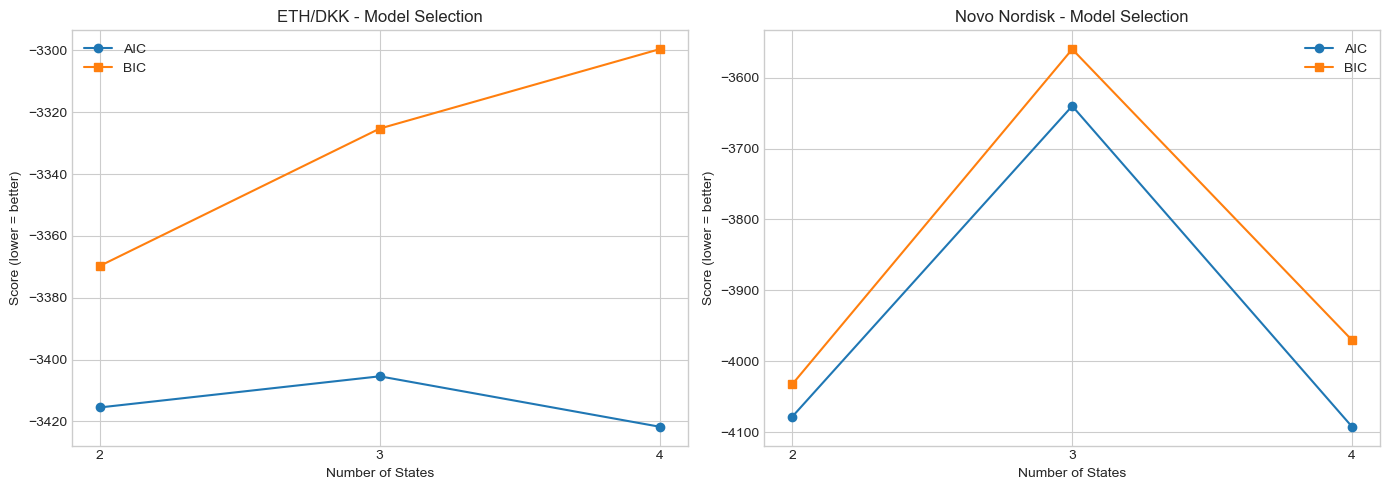

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, name in [(axes[0], eth_results, 'ETH/DKK'),
                           (axes[1], novo_results, 'Novo Nordisk')]:
    states = list(results.keys())
    aics = [results[n]['aic'] for n in states]
    bics = [results[n]['bic'] for n in states]
    
    ax.plot(states, aics, 'o-', label='AIC')
    ax.plot(states, bics, 's-', label='BIC')
    ax.set_title(f'{name} - Model Selection')
    ax.set_xlabel('Number of States')
    ax.set_ylabel('Score (lower = better)')
    ax.set_xticks(states)
    ax.legend()

plt.tight_layout()
plt.show()

Plots AIC and BIC scores for 2, 3, and 4 states. Lower is better. Both assets select 2 states by BIC.

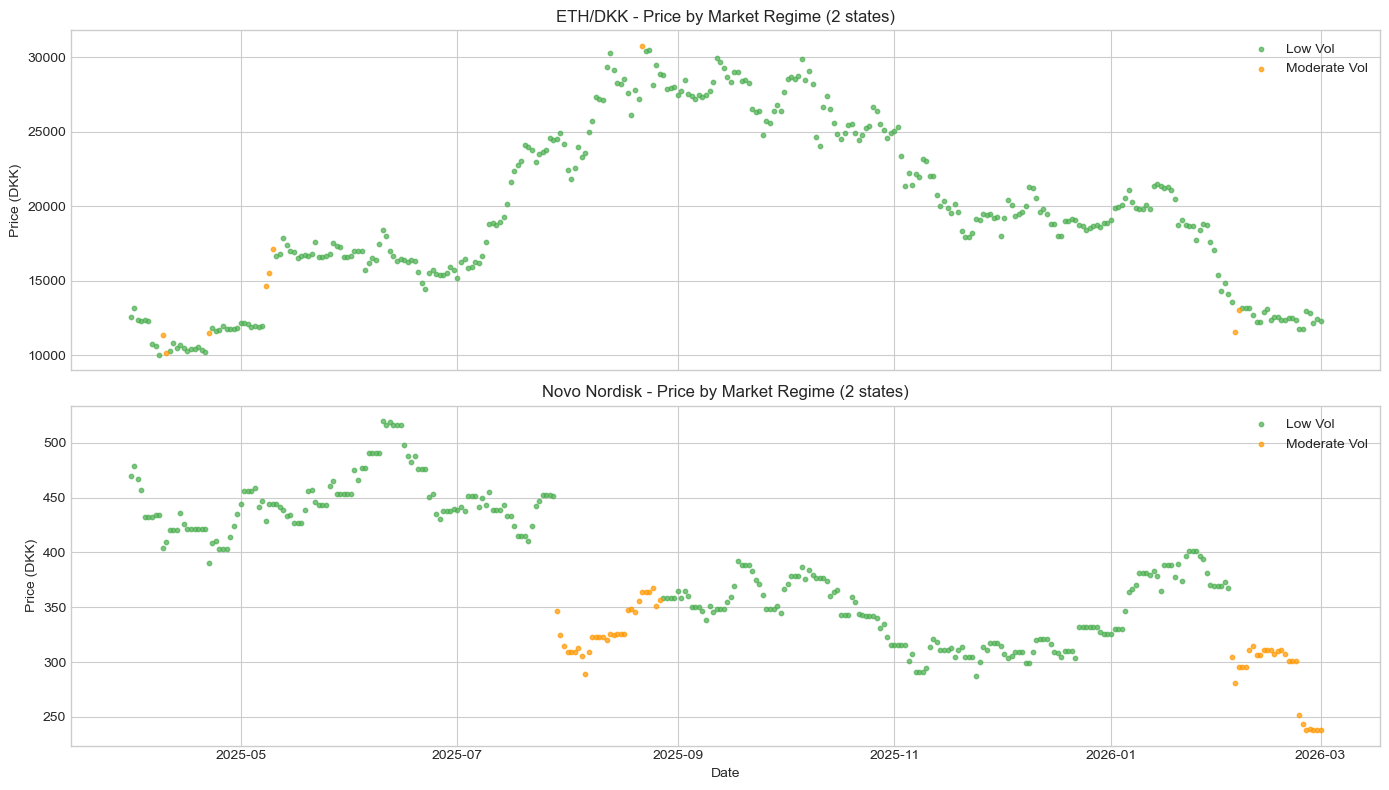

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, regimes, close_col, name, n_states in [
    (axes[0], eth_regimes, 'Close_eth', 'ETH/DKK', eth_n),
    (axes[1], novo_regimes, 'Close_novo', 'Novo Nordisk', novo_n)
]:
    prices = df_combined.loc[regimes.index, close_col]
    colors = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']
    
    # Sort regimes by mean volatility so 0 = lowest vol
    regime_vol = regimes.groupby('regime')['rolling_vol_30'].mean().sort_values()
    label_map = {old: new for new, old in enumerate(regime_vol.index)}
    regimes_sorted = regimes['regime'].map(label_map)
    
    regime_names = ['Low Vol', 'Moderate Vol', 'High Vol', 'Extreme Vol'][:n_states]
    
    for regime in range(n_states):
        mask = regimes_sorted == regime
        ax.scatter(regimes.index[mask], prices[mask],
                   c=colors[regime], s=10, label=regime_names[regime], alpha=0.7)
    
    ax.set_title(f'{name} - Price by Market Regime ({n_states} states)')
    ax.set_ylabel('Price (DKK)')
    ax.legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

Scatter plot of prices colored by regime state. Regimes are sorted by mean volatility so 0 = low-vol (green), 1 = high-vol (orange). Shows when each regime occurs over time.

In [21]:
for name, regimes, n_states in [('ETH/DKK', eth_regimes, eth_n),
                                 ('Novo Nordisk', novo_regimes, novo_n)]:
    regime_vol = regimes.groupby('regime')['rolling_vol_30'].mean().sort_values()
    label_map = {old: new for new, old in enumerate(regime_vol.index)}
    regimes['regime_sorted'] = regimes['regime'].map(label_map)
    
    regime_names = ['Low Vol', 'Moderate Vol', 'High Vol', 'Extreme Vol'][:n_states]
    
    print(f"\n=== {name} ===")
    for regime in range(n_states):
        mask = regimes['regime_sorted'] == regime
        subset = regimes[mask]
        print(f"\n{regime_names[regime]} ({mask.sum()} days, {mask.sum()/len(regimes)*100:.0f}%):")
        print(f"  Avg daily return: {subset['return'].mean():.4f}")
        print(f"  Avg rolling vol:  {subset['rolling_vol_30'].mean():.4f}")


=== ETH/DKK ===

Low Vol (327 days, 97%):
  Avg daily return: -0.0012
  Avg rolling vol:  0.0380

Moderate Vol (9 days, 3%):
  Avg daily return: 0.0717
  Avg rolling vol:  0.0499

=== Novo Nordisk ===

Low Vol (280 days, 83%):
  Avg daily return: 0.0002
  Avg rolling vol:  0.0230

Moderate Vol (56 days, 17%):
  Avg daily return: -0.0105
  Avg rolling vol:  0.0467


Prints summary stats per regime: how many days, average daily return, and average rolling volatility. This tells us what each regime "looks like" in practice.

**Note on rolling window choice:** We use a 30-day rolling window for regime detection as it captures medium-term volatility shifts without being too noisy (shorter windows) or too slow to react (longer windows). Additional rolling windows (7-day, 14-day) will be computed in Section 2.1 as features for prediction models at different horizons.

### 1.4 Anomaly Detection

We use two approaches to flag extreme return events. First, a simple z-score method (flag days beyond ±3 standard deviations). Second, Isolation Forest (covered in L07), which isolates anomalies by randomly partitioning data. Points that are easier to isolate score higher. We compare which events both methods agree on.

In [22]:
from sklearn.ensemble import IsolationForest

def detect_anomalies(returns, asset_name, z_thresh=3, contamination='auto', use_rolling_vol=False):
    """Detect anomalies using z-score and Isolation Forest."""
    df_anom = pd.DataFrame({'return': returns}).dropna()
    
    # Z-score method
    mean, std = df_anom['return'].mean(), df_anom['return'].std()
    df_anom['z_score'] = (df_anom['return'] - mean) / std
    df_anom['zscore_anomaly'] = df_anom['z_score'].abs() > z_thresh
    
    # Isolation Forest
    df_anom['rolling_vol_30'] = df_anom['return'].rolling(30).std()
    
    if use_rolling_vol:
        features = df_anom[['return', 'rolling_vol_30']].dropna()
    else:
        features = df_anom[['return']].dropna()
    
    iso = IsolationForest(contamination=contamination, random_state=42)
    df_anom.loc[features.index, 'iso_anomaly'] = iso.fit_predict(features) == -1
    df_anom['iso_anomaly'] = df_anom['iso_anomaly'].fillna(False).astype(bool)
    
    # Agreement
    df_anom['both'] = df_anom['zscore_anomaly'] & df_anom['iso_anomaly']
    
    n_z = df_anom['zscore_anomaly'].sum()
    n_iso = df_anom['iso_anomaly'].sum()
    n_both = df_anom['both'].sum()
    
    print(f"\n=== {asset_name} ===")
    print(f"Z-score (±{z_thresh}σ): {n_z} anomalies")
    print(f"Isolation Forest ({contamination}): {n_iso} anomalies")
    print(f"Both methods agree: {n_both} anomalies")
    
    return df_anom

# Baseline: ±3σ, IsolationForest with auto contamination, returns only
print("--- BASELINE (±3σ, contamination=auto, returns only) ---")
eth_anom_v1 = detect_anomalies(df_combined['Return_eth'], 'ETH/DKK')
novo_anom_v1 = detect_anomalies(df_combined['Return_novo'], 'Novo Nordisk')

--- BASELINE (±3σ, contamination=auto, returns only) ---

=== ETH/DKK ===
Z-score (±3σ): 9 anomalies
Isolation Forest (auto): 61 anomalies
Both methods agree: 9 anomalies

=== Novo Nordisk ===
Z-score (±3σ): 4 anomalies
Isolation Forest (auto): 50 anomalies
Both methods agree: 4 anomalies


Baseline anomaly detection. Z-score flags days beyond ±3 standard deviations. IsolationForest isolates anomalies by random partitioning (points easier to isolate = more anomalous). We check where both methods agree for high-confidence anomalies.

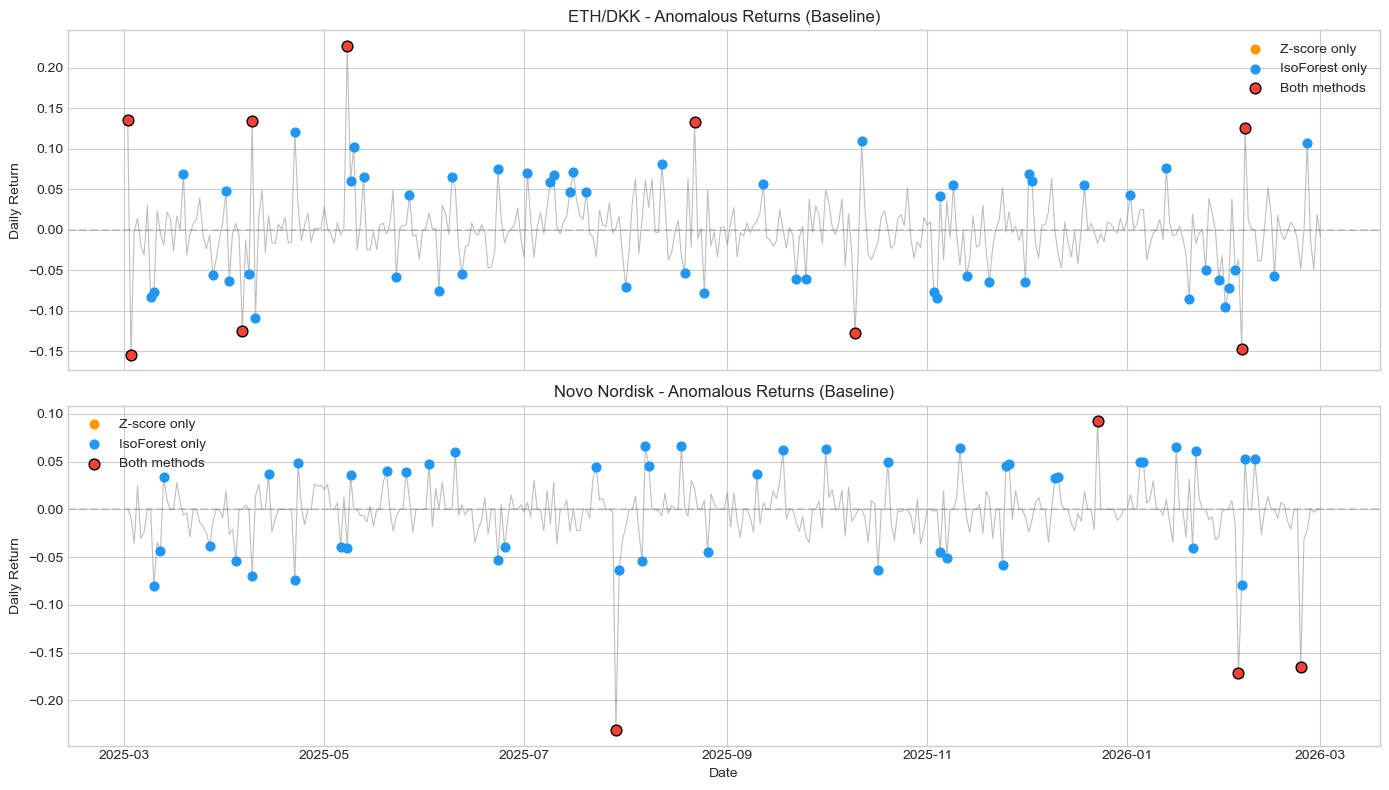

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, anom, close_col, name in [
    (axes[0], eth_anom_v1, 'Close_eth', 'ETH/DKK'),
    (axes[1], novo_anom_v1, 'Close_novo', 'Novo Nordisk')
]:
    # Plot returns
    ax.plot(anom.index, anom['return'], color='gray', alpha=0.5, linewidth=0.8)
    
    # Z-score only
    z_only = anom['zscore_anomaly'] & ~anom['iso_anomaly']
    ax.scatter(anom.index[z_only], anom.loc[z_only, 'return'],
               c='#FF9800', s=40, label='Z-score only', zorder=3)
    
    # Isolation Forest only
    iso_only = anom['iso_anomaly'] & ~anom['zscore_anomaly']
    ax.scatter(anom.index[iso_only], anom.loc[iso_only, 'return'],
               c='#2196F3', s=40, label='IsoForest only', zorder=3)
    
    # Both methods
    both = anom['both']
    ax.scatter(anom.index[both], anom.loc[both, 'return'],
               c='#F44336', s=60, label='Both methods', zorder=4, edgecolors='black')
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_title(f'{name} - Anomalous Returns (Baseline)')
    ax.set_ylabel('Daily Return')
    ax.legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

Plots daily returns with anomalies highlighted. Orange = z-score only, blue = IsolationForest only, red = both methods agree.

**Improving the anomaly detection:**

The baseline IsolationForest with `contamination='auto'` flags too many days (~15%) because the default threshold isn't calibrated for volatile assets. Two improvements:

1. **Lower z-score to ±2σ** - for crypto and a volatile stock, ±3σ is too strict. ±2σ captures more meaningful swings while still filtering noise.
2. **Add rolling volatility as a feature to IsolationForest** - a -5% day during a calm period is more anomalous than during a turbulent period. Adding context makes the detection regime-aware.
3. **Set `contamination=0.03`** - explicitly expect ~3% of days to be anomalous, more reasonable than the liberal `auto` default.

In [24]:
# Improved: ±2σ, contamination=0.03, rolling vol as second feature
print("--- IMPROVED (±2σ, contamination=0.03, returns + rolling vol) ---")
eth_anom = detect_anomalies(df_combined['Return_eth'], 'ETH/DKK',
                            z_thresh=2, contamination=0.03, use_rolling_vol=True)
novo_anom = detect_anomalies(df_combined['Return_novo'], 'Novo Nordisk',
                             z_thresh=2, contamination=0.03, use_rolling_vol=True)

--- IMPROVED (±2σ, contamination=0.03, returns + rolling vol) ---

=== ETH/DKK ===
Z-score (±2σ): 18 anomalies
Isolation Forest (0.03): 11 anomalies
Both methods agree: 10 anomalies

=== Novo Nordisk ===
Z-score (±2σ): 18 anomalies
Isolation Forest (0.03): 11 anomalies
Both methods agree: 7 anomalies


Improved version: lowers z-score to ±2σ (better for volatile assets), sets IsolationForest contamination to 3% (instead of auto which flagged ~15%), and adds rolling volatility as a second feature so the model can distinguish "big move in calm market" from "big move in turbulent market."

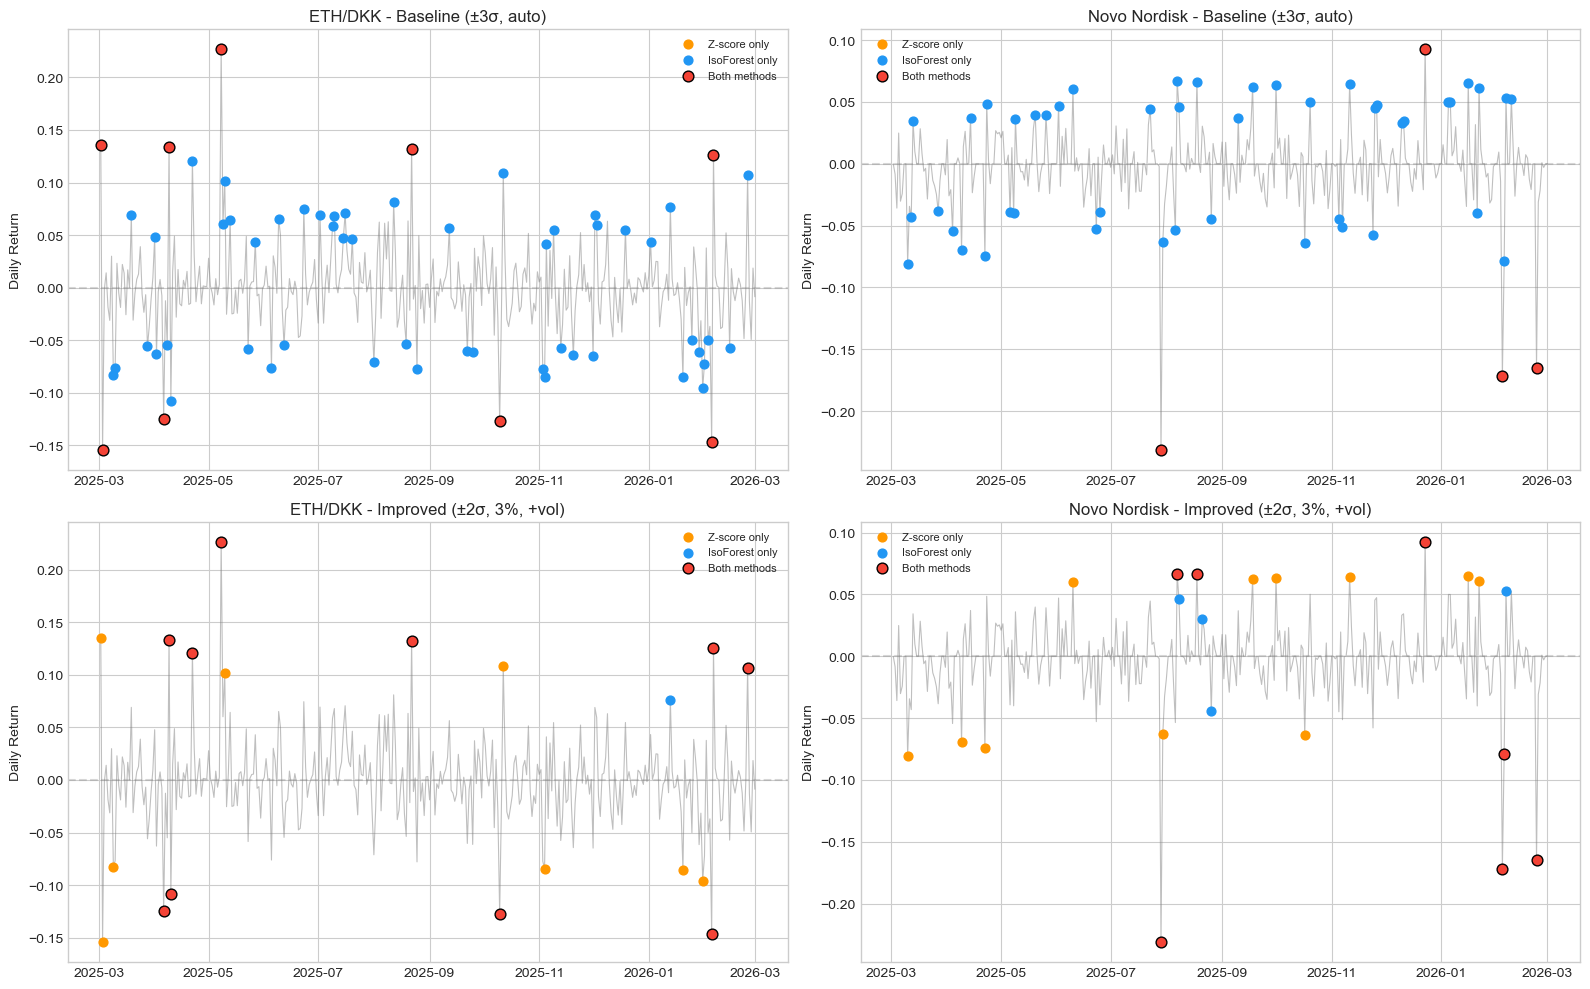

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (anom_v1, anom_v2, name) in enumerate([
    (eth_anom_v1, eth_anom, 'ETH/DKK'),
    (novo_anom_v1, novo_anom, 'Novo Nordisk')
]):
    for row, (anom, label) in enumerate([
        (anom_v1, 'Baseline (±3σ, auto)'),
        (anom_v2, 'Improved (±2σ, 3%, +vol)')
    ]):
        ax = axes[row][col]
        ax.plot(anom.index, anom['return'], color='gray', alpha=0.5, linewidth=0.8)
        
        z_only = anom['zscore_anomaly'] & ~anom['iso_anomaly']
        ax.scatter(anom.index[z_only], anom.loc[z_only, 'return'],
                   c='#FF9800', s=40, label='Z-score only', zorder=3)
        
        iso_only = anom['iso_anomaly'] & ~anom['zscore_anomaly']
        ax.scatter(anom.index[iso_only], anom.loc[iso_only, 'return'],
                   c='#2196F3', s=40, label='IsoForest only', zorder=3)
        
        both = anom['both']
        ax.scatter(anom.index[both], anom.loc[both, 'return'],
                   c='#F44336', s=60, label='Both methods', zorder=4, edgecolors='black')
        
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
        ax.set_title(f'{name} - {label}')
        ax.set_ylabel('Daily Return')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

2x2 comparison: baseline (top) vs improved (bottom) for each asset. Shows how the tuned parameters produce more focused anomaly detection.

### 1.5 Crash Regime Probabilities

Using the transition matrices from the fitted HMMs, we extract the probability of moving between regimes on any given day. We also compute the steady-state distribution, which represents the long-run proportion of time spent in each regime.

In [26]:
for name, model, regimes, n_states in [('ETH/DKK', eth_hmm, eth_regimes, eth_n),
                                        ('Novo Nordisk', novo_hmm, novo_regimes, novo_n)]:
    # Sort regimes by volatility so index 0 = low vol
    regime_vol = regimes.groupby('regime')['rolling_vol_30'].mean().sort_values()
    vol_order = list(regime_vol.index)
    
    # Reorder transition matrix to match low-vol → high-vol ordering
    transmat = model.transmat_[np.ix_(vol_order, vol_order)]
    
    regime_names = ['Low Vol', 'High Vol'][:n_states]
    
    print(f"\n=== {name} - Transition Matrix (daily) ===")
    print(f"{'From \\ To':<12}", end='')
    for rn in regime_names:
        print(f"{rn:>12}", end='')
    print()
    for i, rn in enumerate(regime_names):
        print(f"{rn:<12}", end='')
        for j in range(n_states):
            print(f"{transmat[i, j]:>11.1%}", end='')
        print()
    
    # Steady-state distribution (left eigenvector of transition matrix)
    eigenvalues, eigenvectors = np.linalg.eig(transmat.T)
    stationary_idx = np.argmin(np.abs(eigenvalues - 1.0))
    stationary = np.real(eigenvectors[:, stationary_idx])
    stationary = stationary / stationary.sum()
    
    print(f"\nSteady-state distribution:")
    for rn, prob in zip(regime_names, stationary):
        print(f"  {rn}: {prob:.1%}")


=== ETH/DKK - Transition Matrix (daily) ===
From \ To        Low Vol    High Vol
Low Vol           97.4%       2.6%
High Vol          62.4%      37.6%

Steady-state distribution:
  Low Vol: 96.0%
  High Vol: 4.0%

=== Novo Nordisk - Transition Matrix (daily) ===
From \ To        Low Vol    High Vol
Low Vol           99.3%       0.7%
High Vol           1.8%      98.2%

Steady-state distribution:
  Low Vol: 71.8%
  High Vol: 28.2%


Extracts the HMM transition matrix (probability of moving between regimes on any given day) and computes the steady-state distribution (long-run proportion of time in each regime) via eigenvalue decomposition. Key output: how "sticky" each regime is and how much time the asset spends in crash mode.

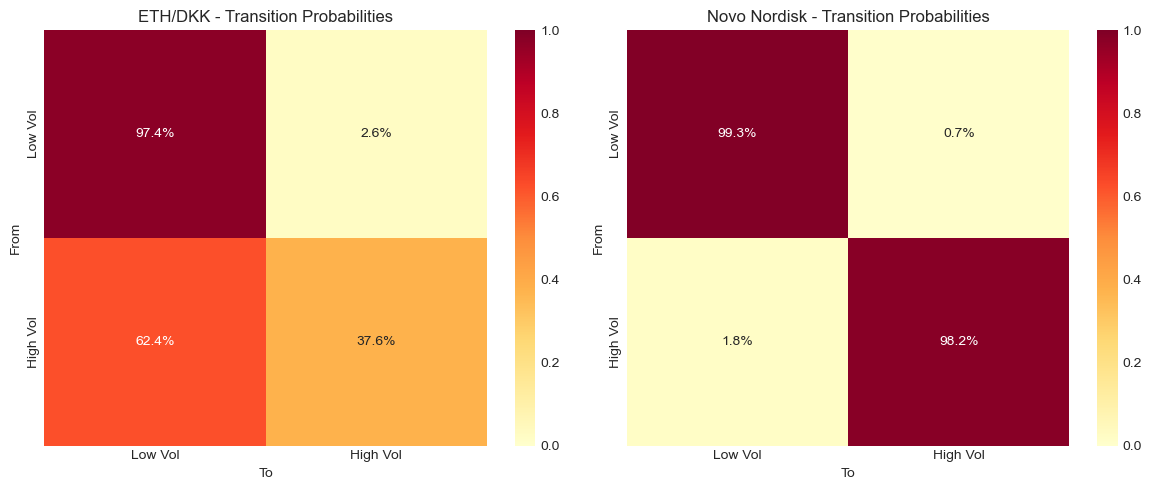

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, regimes, name, n_states in [
    (axes[0], eth_hmm, eth_regimes, 'ETH/DKK', eth_n),
    (axes[1], novo_hmm, novo_regimes, 'Novo Nordisk', novo_n)
]:
    regime_vol = regimes.groupby('regime')['rolling_vol_30'].mean().sort_values()
    vol_order = list(regime_vol.index)
    transmat = model.transmat_[np.ix_(vol_order, vol_order)]
    
    regime_names = ['Low Vol', 'High Vol'][:n_states]
    
    sns.heatmap(transmat, annot=True, fmt='.1%', cmap='YlOrRd',
                xticklabels=regime_names, yticklabels=regime_names,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{name} - Transition Probabilities')
    ax.set_xlabel('To')
    ax.set_ylabel('From')

plt.tight_layout()
plt.show()

Heatmap of transition probabilities. Diagonal = staying in same regime (persistence). Off-diagonal = switching. High diagonal values = sticky regime.

### RQ1 Summary

Both assets lost money over the period. ETH dropped 22.7% (193,259 DKK) while Novo fell 63.1% (92,281 DKK). On a risk-adjusted basis, ETH's Sharpe ratio (-0.33) is significantly better than Novo's (-1.17), despite ETH having higher daily volatility (4.1% vs 3.5%).

HMM regime detection found 2 states for both assets. ETH spends 97% of the time in a low-volatility regime with a slow bleed (-0.12% avg daily), and its rare high-volatility days are actually positive (+7.2% avg). Novo spends 83% in low-vol (flat) but its high-vol regime is a persistent crash (-1.05% avg daily).

The transition matrices tell the most important story: ETH exits its high-vol regime quickly (62% daily exit probability), while Novo gets stuck (only 1.8% exit probability, 98.2% persistence). In steady state, Novo spends 28% of the time in its crash regime vs ETH's 4%.

Anomaly detection (z-score ±2σ and IsolationForest with rolling volatility) confirms both assets experience extreme events, but Novo's cluster in sustained downtrends while ETH's are more isolated spikes.

---

## RQ2: Capital Allocation Strategy

**How should the DKK 250,000 be allocated? Pure strategy (100% one asset) or hybrid (X% crypto, Y% stock)? What investment horizon (short-term vs. long-term)?**

**Approach:**
- Build supervised learning models to predict next-day/next-week/next-month returns or return direction
- Use a robust baseline model and compare against more complex models
- Incorporate regularization techniques to prevent overfitting
- Apply systematic feature selection to identify economically meaningful predictors
- Use interpretable models (e.g., decision trees, logistic regression) to extract transparent investment decision rules
- Simulate portfolio allocations under different strategies and horizons

**Note on data separation:** From this section onward, we build features and train models on each asset independently using `df_eth` and `df_novo` rather than the combined DataFrame. Novo only trades on weekdays (250 days/year), and the forward-filled weekend prices in `df_combined` would create artificial 0% returns that pollute the feature set. Keeping them separate ensures each model trains on genuine price movements.

### 2.1 Feature Engineering

We build predictive features separately for each asset to avoid artifacts from forward-filled weekend prices in the combined DataFrame. Features include lagged returns, rolling statistics, price ratios, and temporal indicators. Target: next-day return (regression) and next-day direction (classification).

In [28]:
def build_features(df, asset_name):
    """Build predictive features from OHLCV data."""
    feat = pd.DataFrame(index=df.index)
    
    # Daily return
    feat['return'] = df['Close'].pct_change()
    
    # Lagged returns
    for lag in [1, 3, 5, 7]:
        feat[f'return_lag_{lag}'] = feat['return'].shift(lag)
    
    # Rolling mean return
    for window in [7, 14, 30]:
        feat[f'return_mean_{window}'] = feat['return'].rolling(window).mean()
    
    # Rolling volatility
    for window in [7, 14, 30]:
        feat[f'volatility_{window}'] = feat['return'].rolling(window).std()
    
    # Price ratios
    feat['close_open_ratio'] = df['Close'] / df['Open']
    feat['high_low_ratio'] = df['High'] / df['Low']
    
    # Temporal features
    feat['day_of_week'] = df.index.dayofweek
    feat['day_of_month'] = df.index.day
    feat['month'] = df.index.month
    
    # Targets: next-day return and direction
    feat['target_return'] = feat['return'].shift(-1)
    feat['target_direction'] = (feat['target_return'] > 0).astype(int)
    
    # Drop rows with NaN (from rolling windows and lagged features)
    feat = feat.dropna()
    
    print(f"\n=== {asset_name} ===")
    print(f"Shape: {feat.shape} | Features: {feat.shape[1] - 2} | Samples: {feat.shape[0]}")
    print(f"Direction balance: {feat['target_direction'].mean():.1%} up days")
    
    return feat

feat_eth = build_features(df_eth, 'ETH/DKK')
feat_novo = build_features(df_novo, 'Novo Nordisk')

feat_eth.head()


=== ETH/DKK ===
Shape: (335, 18) | Features: 16 | Samples: 335
Direction balance: 49.9% up days

=== Novo Nordisk ===
Shape: (219, 18) | Features: 16 | Samples: 219
Direction balance: 47.5% up days


,return,return_lag_1,return_lag_3,return_lag_5,return_lag_7,return_mean_7,return_mean_14,return_mean_30,volatility_7,volatility_14,volatility_30,close_open_ratio,high_low_ratio,day_of_week,day_of_month,month,target_return,target_direction
Date,,,,,,,,,,,,,,,,,,
2025-03-31,0.009428,-0.011126,-0.055968,-0.023581,0.038907,-0.018726,-0.002805,-0.006655,0.021882,0.031301,0.049655,1.008126,1.043602,0,31,3,0.047842,1
2025-04-01,0.047842,0.009428,-0.036588,-0.006810,-0.006440,-0.010972,0.000603,-0.009581,0.033497,0.034116,0.043141,1.045297,1.060521,1,1,4,-0.062932,0
2025-04-02,-0.062932,0.047842,-0.011126,-0.055968,-0.023581,-0.016593,-0.008833,-0.006533,0.038842,0.031889,0.035026,0.942382,1.098494,2,2,4,-0.004020,0
2025-04-03,-0.004020,-0.062932,0.009428,-0.036588,-0.006810,-0.016195,-0.006902,-0.006617,0.038973,0.031252,0.035016,1.012266,1.054434,3,3,4,0.007708,1
2025-04-04,0.007708,-0.004020,0.047842,-0.011126,-0.055968,-0.007098,-0.005934,-0.006827,0.035411,0.031496,0.034907,0.999802,1.043760,4,4,4,-0.007727,0


Builds 16 features per asset from OHLCV data: lagged returns (1,3,5,7 days), rolling mean returns (7,14,30 days), rolling volatility (7,14,30 days), price ratios, and temporal features. Target variables are next-day return (regression) and next-day direction (classification). Uses separate DataFrames per asset to avoid forward-fill contamination.

### 2.2 Feature Selection

We use two methods to identify the most meaningful predictors: LASSO (L1 regularization zeros out irrelevant features) and Random Forest feature importance (Gini-based ranking). Features selected by both methods are kept. We then take the union across both assets so both are evaluated on the same feature set for fair comparison in RQ2.

In [29]:
def select_features(feat, asset_name):
    """Feature selection via LASSO and RF importance."""
    
    # Separate features and targets
    target_cols = ['target_return', 'target_direction']
    feature_cols = [c for c in feat.columns if c not in target_cols]
    X = feat[feature_cols]
    y = feat['target_return']
    
    # 1. LASSO - which features survive L1?
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    lasso = Lasso(alpha=0.001, random_state=42)
    lasso.fit(X_scaled, y)
    
    lasso_coefs = pd.Series(np.abs(lasso.coef_), index=X.columns).sort_values(ascending=False)
    lasso_nonzero = lasso_coefs[lasso_coefs > 0]
    lasso_zero = lasso_coefs[lasso_coefs == 0]
    
    print(f"\n=== {asset_name} ===")
    print(f"\n1. LASSO - {len(lasso_nonzero)} features kept, {len(lasso_zero)} zeroed out")
    if len(lasso_zero) > 0:
        print(f"   Zeroed: {list(lasso_zero.index)}")
    
    # 2. Random Forest importance
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_scaled, y)
    
    rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    print(f"\n2. RF Feature Importance (top 10):")
    for feat_name, imp in rf_importance.head(10).items():
        marker = " *" if feat_name in lasso_nonzero.index else ""
        print(f"   {feat_name:<25} {imp:.4f}{marker}")
    print("   (* = also selected by LASSO)")
    
    # Final selection: features that both LASSO and RF top-10 agree on
    rf_top10 = set(rf_importance.head(10).index)
    lasso_selected = set(lasso_nonzero.index)
    agreed = rf_top10 & lasso_selected
    
    print(f"\nAgreed features (LASSO nonzero ∩ RF top-10): {agreed}")
    
    return X, lasso_coefs, rf_importance, agreed

X_eth, lasso_eth, rf_eth, agreed_eth = select_features(feat_eth, 'ETH/DKK')
X_novo, lasso_novo, rf_novo, agreed_novo = select_features(feat_novo, 'Novo Nordisk')

# --- Shared feature set (union of agreed features from both assets) ---
# For fair comparison in RQ2, both assets use the same features.
shared_features = sorted(agreed_eth | agreed_novo)
print(f"\n{'='*50}")
print(f"Shared feature set (union): {shared_features}")
print(f"Total: {len(shared_features)} features")


=== ETH/DKK ===

1. LASSO - 7 features kept, 9 zeroed out
   Zeroed: ['return', 'return_lag_5', 'return_lag_7', 'return_mean_7', 'return_mean_30', 'volatility_14', 'close_open_ratio', 'high_low_ratio', 'month']

2. RF Feature Importance (top 10):
   volatility_14             0.1402
   return_mean_7             0.1120
   return_lag_1              0.0840 *
   return_mean_14            0.0726 *
   return_lag_3              0.0713 *
   volatility_30             0.0546 *
   day_of_month              0.0542 *
   return_lag_5              0.0541
   volatility_7              0.0541 *
   return                    0.0541
   (* = also selected by LASSO)

Agreed features (LASSO nonzero ∩ RF top-10): {'return_mean_14', 'return_lag_1', 'volatility_7', 'volatility_30', 'day_of_month', 'return_lag_3'}

=== Novo Nordisk ===

1. LASSO - 7 features kept, 9 zeroed out
   Zeroed: ['return_lag_1', 'return_lag_3', 'return_lag_5', 'return_mean_7', 'return_mean_14', 'return_mean_30', 'volatility_30', 'close_o

Two-step feature selection per asset. LASSO (L1) zeros out irrelevant features via regularization. Random Forest ranks features by Gini importance. Features that both methods agree on (LASSO non-zero AND RF top-10) are kept. The union across both assets gives us the shared feature set for fair comparison.

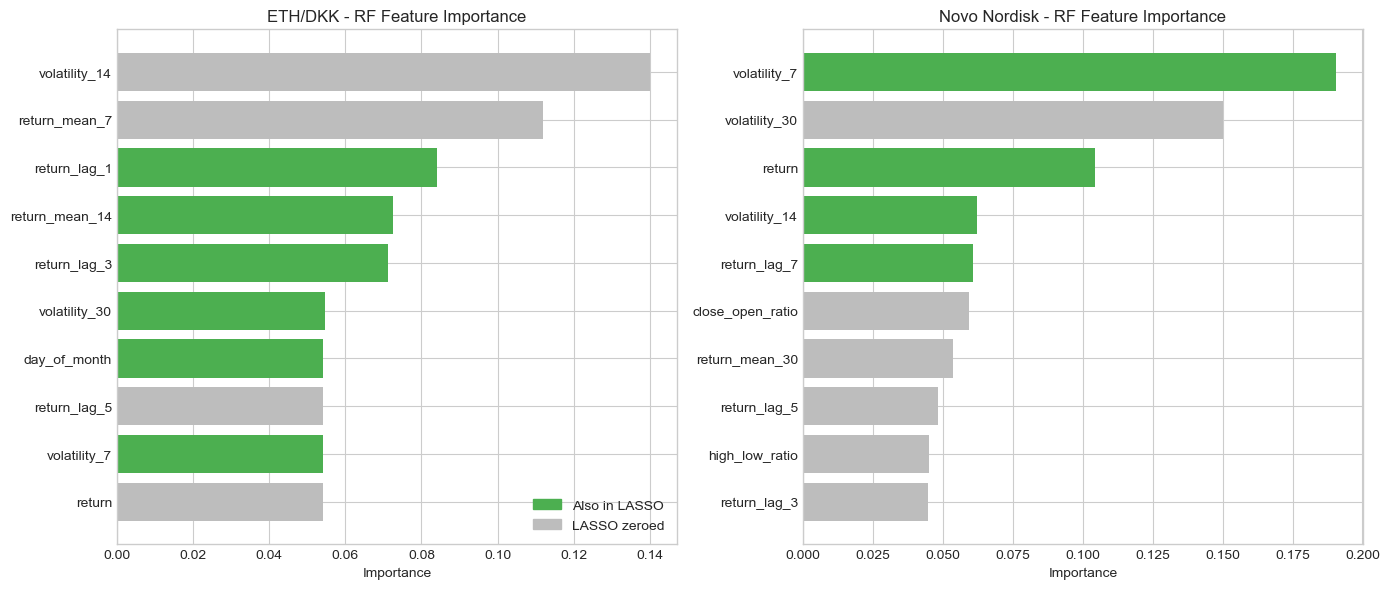

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, rf_imp, lasso_coef, name in [
    (axes[0], rf_eth, lasso_eth, 'ETH/DKK'),
    (axes[1], rf_novo, lasso_novo, 'Novo Nordisk')
]:
    top = rf_imp.head(10)
    colors = ['#4CAF50' if lasso_coef.get(f, 0) > 0 else '#BDBDBD' for f in top.index]
    ax.barh(range(len(top)), top.values, color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index)
    ax.invert_yaxis()
    ax.set_title(f'{name} - RF Feature Importance')
    ax.set_xlabel('Importance')

# Legend
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#4CAF50', label='Also in LASSO'),
                         Patch(color='#BDBDBD', label='LASSO zeroed')],
               loc='lower right')

plt.tight_layout()
plt.show()

Bar chart of RF feature importance. Green = also selected by LASSO, grey = LASSO zeroed it out. Features in green are the most robust predictors.

**Shared feature set:** For fair comparison in RQ2, we use the union of agreed features from both assets rather than per-asset subsets. This way, model performance differences reflect genuine predictability of each asset, not differences in input features. The per-asset selection results above justify *why* these features were chosen — each was independently flagged by both LASSO and RF for at least one asset.

### 2.3 Baseline Model

We establish two baselines for predicting next-day returns: a naive model (predict the training set mean return every day) and Linear Regression. Both assets use the shared feature set from 2.2. If these can't meaningfully predict returns, it motivates the use of more complex models in 2.4.

**Note on cross-validation:** We use `TimeSeriesSplit` (5 splits) instead of standard k-fold CV. Standard k-fold shuffles data randomly, which leaks future information into training folds. TimeSeriesSplit always trains on earlier data and validates on later data, respecting the temporal ordering. The train/test split also uses `shuffle=False` for the same reason.

In [31]:
def prepare_data(feat, shared_features):
    """Prepare train/test split using the shared feature set."""
    X = feat[shared_features]
    y_reg = feat['target_return']
    y_cls = feat['target_direction']
    
    X_train, X_test, y_train_reg, y_test_reg = train_test_split(
        X, y_reg, test_size=0.2, random_state=42, shuffle=False  # time series: no shuffle
    )
    _, _, y_train_cls, y_test_cls = train_test_split(
        X, y_cls, test_size=0.2, random_state=42, shuffle=False
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), 
                                   index=X_train.index, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                                  index=X_test.index, columns=X_test.columns)
    
    print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
    print(f"Test direction balance: {y_test_cls.mean():.1%} up days")
    
    return X_train_scaled, X_test_scaled, y_train_reg, y_test_reg, y_train_cls, y_test_cls, scaler

print("=== ETH/DKK ===")
eth_train_X, eth_test_X, eth_train_y, eth_test_y, eth_train_cls, eth_test_cls, eth_scaler = \
    prepare_data(feat_eth, shared_features)

print("\n=== Novo Nordisk ===")
novo_train_X, novo_test_X, novo_train_y, novo_test_y, novo_train_cls, novo_test_cls, novo_scaler = \
    prepare_data(feat_novo, shared_features)

=== ETH/DKK ===
Train: 268 samples | Test: 67 samples
Test direction balance: 44.8% up days

=== Novo Nordisk ===
Train: 175 samples | Test: 44 samples
Test direction balance: 45.5% up days


Splits each asset into 80% train / 20% test with `shuffle=False` (preserves time order). Scales features with StandardScaler fitted on training data only (no data leakage). Both assets use the same shared feature set.

In [32]:
def evaluate_baselines(X_train, X_test, y_train, y_test, y_train_cls, y_test_cls, asset_name):
    """Evaluate naive mean baseline and Linear Regression."""
    
    results = {}
    
    # --- Regression baselines ---
    print(f"=== {asset_name} - Regression (predict next-day return) ===\n")
    
    # Naive baseline: predict training mean every day
    naive_pred = np.full(len(y_test), y_train.mean())
    naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
    naive_r2 = r2_score(y_test, naive_pred)
    
    print(f"{'Model':<25} {'RMSE':>10} {'R²':>10} {'CV RMSE':>10}")
    print(f"{'Naive (predict mean)':<25} {naive_rmse:>10.6f} {naive_r2:>10.4f} {'N/A':>10}")
    results['Naive'] = {'rmse': naive_rmse, 'r2': naive_r2}
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
    lr_r2 = r2_score(y_test, lr_pred)
    lr_cv = cross_val_score(lr, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
    
    print(f"{'Linear Regression':<25} {lr_rmse:>10.6f} {lr_r2:>10.4f} {-lr_cv.mean():>10.6f}")
    results['LinearRegression'] = {'rmse': lr_rmse, 'r2': lr_r2, 'cv_rmse': -lr_cv.mean()}
    
    # --- Classification baselines ---
    print(f"\n=== {asset_name} - Classification (predict direction: up/down) ===\n")
    
    # Naive: predict majority class
    majority_class = int(y_train_cls.mode()[0])
    naive_cls_pred = np.full(len(y_test_cls), majority_class)
    naive_acc = accuracy_score(y_test_cls, naive_cls_pred)
    
    # Logistic Regression
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(X_train, y_train_cls)
    log_pred = log_reg.predict(X_test)
    log_acc = accuracy_score(y_test_cls, log_pred)
    log_cv = cross_val_score(log_reg, X_train, y_train_cls, cv=tscv, scoring='accuracy')
    
    print(f"{'Model':<25} {'Accuracy':>10} {'CV Accuracy':>12}")
    print(f"{'Naive (majority class)':<25} {naive_acc:>10.1%} {'N/A':>12}")
    print(f"{'Logistic Regression':<25} {log_acc:>10.1%} {log_cv.mean():>12.1%}")
    
    results['Naive_cls'] = {'accuracy': naive_acc}
    results['LogisticRegression'] = {'accuracy': log_acc, 'cv_accuracy': log_cv.mean(), 'model': log_reg}
    results['LinearRegression']['model'] = lr
    
    return results

print("─" * 60)
eth_baseline = evaluate_baselines(eth_train_X, eth_test_X, eth_train_y, eth_test_y,
                                   eth_train_cls, eth_test_cls, 'ETH/DKK')
print("\n" + "─" * 60)
novo_baseline = evaluate_baselines(novo_train_X, novo_test_X, novo_train_y, novo_test_y,
                                    novo_train_cls, novo_test_cls, 'Novo Nordisk')

────────────────────────────────────────────────────────────
=== ETH/DKK - Regression (predict next-day return) ===

Model                           RMSE         R²    CV RMSE
Naive (predict mean)        0.041659    -0.0344        N/A
Linear Regression           0.041078    -0.0057   0.039530

=== ETH/DKK - Classification (predict direction: up/down) ===

Model                       Accuracy  CV Accuracy
Naive (majority class)         44.8%          N/A
Logistic Regression            55.2%        43.2%

────────────────────────────────────────────────────────────
=== Novo Nordisk - Regression (predict next-day return) ===

Model                           RMSE         R²    CV RMSE
Naive (predict mean)        0.048056    -0.0043        N/A
Linear Regression           0.050597    -0.1133   0.036013

=== Novo Nordisk - Classification (predict direction: up/down) ===

Model                       Accuracy  CV Accuracy
Naive (majority class)         54.5%          N/A
Logistic Regression    

Evaluates two baselines. Regression: naive (predict training mean every day) and Linear Regression. Classification: naive (predict majority class) and Logistic Regression. All CV uses TimeSeriesSplit. These set the floor for the tuned models in 2.4.

### 2.4 Supervised Learning Models

**Regression** (predict next-day return): Ridge (L2), LASSO (L1), Random Forest. Ridge and LASSO address the regularization requirement; Random Forest captures non-linear patterns.

**Classification** (predict next-day direction): Decision Tree, Random Forest. Decision Tree feeds into Section 2.5 (interpretable rules); Random Forest provides a stronger ensemble comparison.

All models are tuned via GridSearchCV with TimeSeriesSplit.

In [33]:
# --- Regression models ---

reg_param_grids = {
    'Ridge': (Ridge(random_state=42), {'alpha': [0.01, 0.1, 1.0, 10.0]}),
    'LASSO': (Lasso(random_state=42), {'alpha': [0.0001, 0.001, 0.01, 0.1]}),
    'RF Regressor': (RandomForestRegressor(random_state=42),
                     {'n_estimators': [100, 200], 'max_depth': [3, 5, 10]})
}

def run_regression_models(X_train, X_test, y_train, y_test, asset_name):
    """Train and evaluate regression models with GridSearchCV."""
    results = {}
    
    print(f"=== {asset_name} - Regression Models ===\n")
    print(f"{'Model':<20} {'Best Params':<30} {'CV RMSE':>10} {'Test RMSE':>10} {'Test R²':>10}")
    
    for name, (model, params) in reg_param_grids.items():
        grid = GridSearchCV(model, params, cv=tscv,
                            scoring='neg_root_mean_squared_error', refit=True)
        grid.fit(X_train, y_train)
        
        pred = grid.predict(X_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, pred))
        test_r2 = r2_score(y_test, pred)
        cv_rmse = -grid.best_score_
        
        best_params = str(grid.best_params_).replace("'", "")
        print(f"{name:<20} {best_params:<30} {cv_rmse:>10.6f} {test_rmse:>10.6f} {test_r2:>10.4f}")
        
        results[name] = {
            'model': grid.best_estimator_, 'rmse': test_rmse,
            'r2': test_r2, 'cv_rmse': cv_rmse, 'params': grid.best_params_
        }
    
    return results

eth_reg = run_regression_models(eth_train_X, eth_test_X, eth_train_y, eth_test_y, 'ETH/DKK')
print()
novo_reg = run_regression_models(novo_train_X, novo_test_X, novo_train_y, novo_test_y, 'Novo Nordisk')

=== ETH/DKK - Regression Models ===

Model                Best Params                       CV RMSE  Test RMSE    Test R²
Ridge                {alpha: 10.0}                    0.037339   0.041091    -0.0063
LASSO                {alpha: 0.01}                    0.035434   0.041659    -0.0344
RF Regressor         {max_depth: 3, n_estimators: 200}   0.036734   0.045878    -0.2545

=== Novo Nordisk - Regression Models ===

Model                Best Params                       CV RMSE  Test RMSE    Test R²
Ridge                {alpha: 10.0}                    0.033301   0.050315    -0.1009
LASSO                {alpha: 0.01}                    0.031686   0.048056    -0.0043
RF Regressor         {max_depth: 3, n_estimators: 200}   0.032630   0.048830    -0.0369


Trains Ridge (L2), LASSO (L1), and Random Forest regressors with GridSearchCV over small parameter grids. Reports best hyperparameters, CV RMSE, test RMSE, and R² for each. Ridge/LASSO address the regularization requirement from the assignment.

In [34]:
# --- Classification models ---

cls_param_grids = {
    'Decision Tree': (DecisionTreeClassifier(random_state=42),
                      {'max_depth': [2, 3, 5, 7], 'min_samples_leaf': [5, 10, 20]}),
    'RF Classifier': (RandomForestClassifier(random_state=42),
                      {'n_estimators': [100, 200], 'max_depth': [3, 5, 10]})
}

def run_classification_models(X_train, X_test, y_train, y_test, asset_name):
    """Train and evaluate classification models with GridSearchCV."""
    results = {}
    
    print(f"=== {asset_name} - Classification Models ===\n")
    print(f"{'Model':<20} {'Best Params':<35} {'CV Acc':>10} {'Test Acc':>10}")
    
    for name, (model, params) in cls_param_grids.items():
        grid = GridSearchCV(model, params, cv=tscv, scoring='accuracy', refit=True)
        grid.fit(X_train, y_train)
        
        pred = grid.predict(X_test)
        test_acc = accuracy_score(y_test, pred)
        cv_acc = grid.best_score_
        
        best_params = str(grid.best_params_).replace("'", "")
        print(f"{name:<20} {best_params:<35} {cv_acc:>10.1%} {test_acc:>10.1%}")
        
        results[name] = {
            'model': grid.best_estimator_, 'accuracy': test_acc,
            'cv_accuracy': cv_acc, 'params': grid.best_params_
        }
    
    return results

eth_cls = run_classification_models(eth_train_X, eth_test_X, eth_train_cls, eth_test_cls, 'ETH/DKK')
print()
novo_cls = run_classification_models(novo_train_X, novo_test_X, novo_train_cls, novo_test_cls, 'Novo Nordisk')

=== ETH/DKK - Classification Models ===

Model                Best Params                             CV Acc   Test Acc
Decision Tree        {max_depth: 2, min_samples_leaf: 10}      54.1%      44.8%
RF Classifier        {max_depth: 10, n_estimators: 100}       51.4%      52.2%

=== Novo Nordisk - Classification Models ===

Model                Best Params                             CV Acc   Test Acc
Decision Tree        {max_depth: 3, min_samples_leaf: 20}      55.9%      52.3%
RF Classifier        {max_depth: 5, n_estimators: 100}        54.5%      52.3%


Trains Decision Tree and Random Forest classifiers with GridSearchCV. Decision Tree is kept shallow (max_depth 2-7) for interpretability in Section 2.5. RF provides a stronger ensemble comparison.

In [35]:
# --- Summary comparison ---
print("=" * 75)
print("REGRESSION SUMMARY (Test Set)")
print(f"{'Model':<25} {'ETH RMSE':>10} {'ETH R²':>10} {'Novo RMSE':>10} {'Novo R²':>10}")
print("-" * 75)

# Baselines
print(f"{'Naive (mean)':<25} {eth_baseline['Naive']['rmse']:>10.6f} {eth_baseline['Naive']['r2']:>10.4f} "
      f"{novo_baseline['Naive']['rmse']:>10.6f} {novo_baseline['Naive']['r2']:>10.4f}")
print(f"{'Linear Regression':<25} {eth_baseline['LinearRegression']['rmse']:>10.6f} {eth_baseline['LinearRegression']['r2']:>10.4f} "
      f"{novo_baseline['LinearRegression']['rmse']:>10.6f} {novo_baseline['LinearRegression']['r2']:>10.4f}")

for name in reg_param_grids:
    print(f"{name:<25} {eth_reg[name]['rmse']:>10.6f} {eth_reg[name]['r2']:>10.4f} "
          f"{novo_reg[name]['rmse']:>10.6f} {novo_reg[name]['r2']:>10.4f}")

print("\n" + "=" * 75)
print("CLASSIFICATION SUMMARY (Test Set)")
print(f"{'Model':<25} {'ETH Acc':>10} {'ETH CV':>10} {'Novo Acc':>10} {'Novo CV':>10}")
print("-" * 75)

# Baselines
print(f"{'Naive (majority)':<25} {eth_baseline['Naive_cls']['accuracy']:>10.1%} {'N/A':>10} "
      f"{novo_baseline['Naive_cls']['accuracy']:>10.1%} {'N/A':>10}")
print(f"{'Logistic Regression':<25} {eth_baseline['LogisticRegression']['accuracy']:>10.1%} "
      f"{eth_baseline['LogisticRegression']['cv_accuracy']:>10.1%} "
      f"{novo_baseline['LogisticRegression']['accuracy']:>10.1%} "
      f"{novo_baseline['LogisticRegression']['cv_accuracy']:>10.1%}")

for name in cls_param_grids:
    print(f"{name:<25} {eth_cls[name]['accuracy']:>10.1%} {eth_cls[name]['cv_accuracy']:>10.1%} "
          f"{novo_cls[name]['accuracy']:>10.1%} {novo_cls[name]['cv_accuracy']:>10.1%}")

REGRESSION SUMMARY (Test Set)
Model                       ETH RMSE     ETH R²  Novo RMSE    Novo R²
---------------------------------------------------------------------------
Naive (mean)                0.041659    -0.0344   0.048056    -0.0043
Linear Regression           0.041078    -0.0057   0.050597    -0.1133
Ridge                       0.041091    -0.0063   0.050315    -0.1009
LASSO                       0.041659    -0.0344   0.048056    -0.0043
RF Regressor                0.045878    -0.2545   0.048830    -0.0369

CLASSIFICATION SUMMARY (Test Set)
Model                        ETH Acc     ETH CV   Novo Acc    Novo CV
---------------------------------------------------------------------------
Naive (majority)               44.8%        N/A      54.5%        N/A
Logistic Regression            55.2%      43.2%      50.0%      46.9%
Decision Tree                  44.8%      54.1%      52.3%      55.9%
RF Classifier                  52.2%      51.4%      52.3%      54.5%


Side-by-side comparison table of all models (baselines + tuned) across both assets. Regression: RMSE and R². Classification: accuracy and CV accuracy. Makes it easy to see if any model beats the baseline.

No model reliably predicts next-day returns or direction for either asset. LASSO zeroed out all coefficients, confirming no linear signal survives regularization. Classification accuracy hovers around 50%, barely above a coin flip. This suggests short-term movements are dominated by noise, not learnable patterns. For RQ2, this means the allocation strategy should rely on risk characteristics (volatility, regime behavior, crash probabilities) rather than return forecasting, and favors a longer-term investment horizon over short-term trading.

### 2.5 Interpretable Decision Rules

We extract the decision rules from the tuned Decision Tree classifiers to understand what signals (if any) the models use to predict market direction. Even with limited accuracy, the tree structure reveals which features and thresholds the model considers most informative.

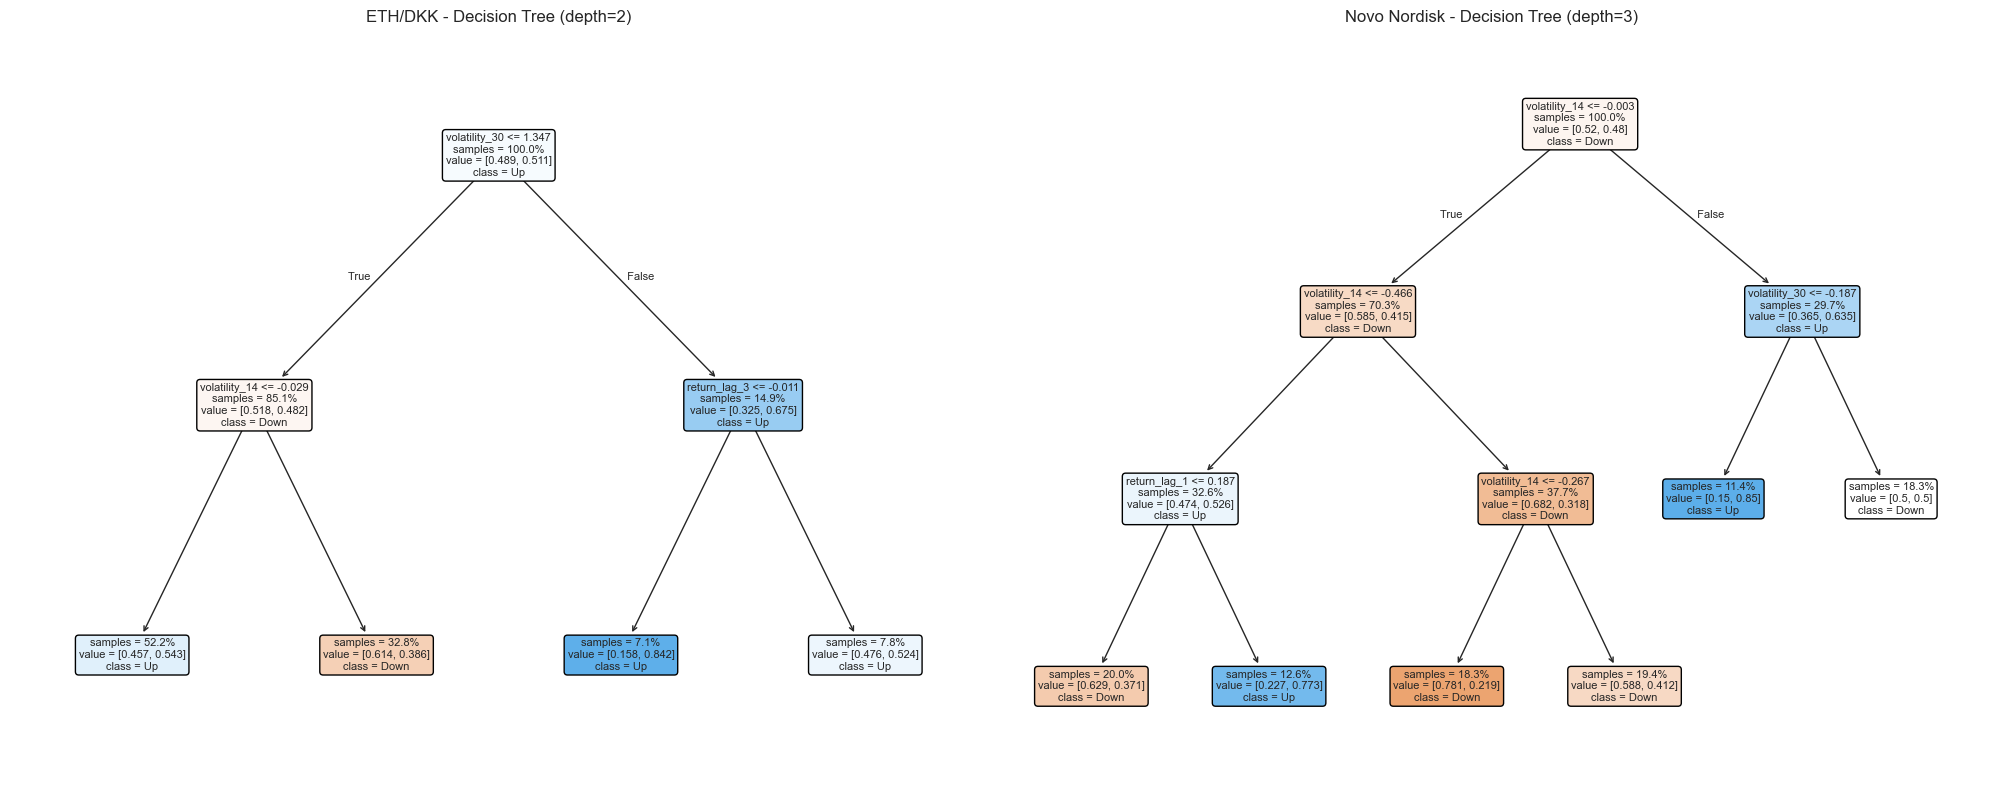


=== ETH/DKK - Decision Rules ===
|--- volatility_30 <= 1.3468
|   |--- volatility_14 <= -0.0287
|   |   |--- class: 1
|   |--- volatility_14 >  -0.0287
|   |   |--- class: 0
|--- volatility_30 >  1.3468
|   |--- return_lag_3 <= -0.0108
|   |   |--- class: 1
|   |--- return_lag_3 >  -0.0108
|   |   |--- class: 1


=== Novo Nordisk - Decision Rules ===
|--- volatility_14 <= -0.0031
|   |--- volatility_14 <= -0.4663
|   |   |--- return_lag_1 <= 0.1873
|   |   |   |--- class: 0
|   |   |--- return_lag_1 >  0.1873
|   |   |   |--- class: 1
|   |--- volatility_14 >  -0.4663
|   |   |--- volatility_14 <= -0.2669
|   |   |   |--- class: 0
|   |   |--- volatility_14 >  -0.2669
|   |   |   |--- class: 0
|--- volatility_14 >  -0.0031
|   |--- volatility_30 <= -0.1870
|   |   |--- class: 1
|   |--- volatility_30 >  -0.1870
|   |   |--- class: 0



In [36]:
from sklearn.tree import plot_tree, export_text

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, cls_results, name in [
    (axes[0], eth_cls, 'ETH/DKK'),
    (axes[1], novo_cls, 'Novo Nordisk')
]:
    tree_model = cls_results['Decision Tree']['model']
    plot_tree(tree_model, feature_names=shared_features,
              class_names=['Down', 'Up'], filled=True, rounded=True,
              fontsize=8, ax=ax, impurity=False, proportion=True)
    ax.set_title(f'{name} - Decision Tree (depth={tree_model.get_depth()})')

plt.tight_layout()
plt.show()

# Print text rules
for cls_results, name in [(eth_cls, 'ETH/DKK'), (novo_cls, 'Novo Nordisk')]:
    tree_model = cls_results['Decision Tree']['model']
    print(f"\n=== {name} - Decision Rules ===")
    print(export_text(tree_model, feature_names=shared_features, decimals=4))

Visualizes the Decision Tree structure using `plot_tree` and prints text rules via `export_text`. Shows which features and thresholds the tree uses to predict up/down. Note: thresholds are in z-score units (scaled features).

### 2.6 Portfolio Simulation

We simulate four strategies on the test period for each asset to compare long-term vs short-term approaches:

1. **Buy & Hold** - invest on day 1 of the test period, hold until the end. Pure long-term.
2. **Decision Tree trading** - use the interpretable rules from 2.5 to predict direction. Go long on "up", cash on "down". Includes 0.1% transaction cost per trade.
3. **RF trading** - same as above but using the Random Forest classifier. Tests whether a stronger model improves on the simple rules.
4. **Regime-based switching** - use HMM regime states. Go to cash during high-volatility regimes, invest during low-volatility. Includes 0.1% transaction cost per switch.

If buy & hold outperforms the active strategies, it reinforces that a longer-term horizon is more appropriate than short-term trading.

In [42]:
TRANSACTION_COST = 0.001  # 0.1% per trade

def simulate_strategies(feat, X_test_scaled, y_test_cls, dt_model, rf_model,
                        hmm_model, hmm_regimes, asset_name):
    """Simulate four strategies on the test period."""
    
    test_dates = X_test_scaled.index
    test_returns = feat.loc[test_dates, 'target_return'].values
    
    # --- 1. Buy & Hold ---
    bh_portfolio = np.cumprod(1 + test_returns)
    
    # --- 2. Decision Tree trading ---
    dt_preds = dt_model.predict(X_test_scaled)
    dt_positions = dt_preds.copy()  # 1 = long, 0 = cash
    dt_trades = np.abs(np.diff(dt_positions, prepend=1))  # count switches
    dt_costs = dt_trades * TRANSACTION_COST
    dt_daily = dt_positions * test_returns - dt_costs
    dt_portfolio = np.cumprod(1 + dt_daily)
    
    # --- 3. RF trading ---
    rf_preds = rf_model.predict(X_test_scaled)
    rf_positions = rf_preds.copy()
    rf_trades = np.abs(np.diff(rf_positions, prepend=1))
    rf_costs = rf_trades * TRANSACTION_COST
    rf_daily = rf_positions * test_returns - rf_costs
    rf_portfolio = np.cumprod(1 + rf_daily)
    
    # --- 4. Regime-based switching ---
    # Get regime for each test date using HMM
    regime_vol = hmm_regimes.groupby('regime')['rolling_vol_30'].mean().sort_values()
    label_map = {old: new for new, old in enumerate(regime_vol.index)}
    
    # For test dates that overlap with regime data, get regime state
    regime_positions = np.ones(len(test_dates))  # default: invested
    for i, date in enumerate(test_dates):
        if date in hmm_regimes.index:
            raw_regime = hmm_regimes.loc[date, 'regime']
            sorted_regime = label_map[raw_regime]
            if sorted_regime > 0:  # high-vol regime → cash
                regime_positions[i] = 0
    
    regime_trades = np.abs(np.diff(regime_positions, prepend=1))
    regime_costs = regime_trades * TRANSACTION_COST
    regime_daily = regime_positions * test_returns - regime_costs
    regime_portfolio = np.cumprod(1 + regime_daily)
    
    # --- Results ---
    results = {
        'Buy & Hold': {'final': bh_portfolio[-1], 'portfolio': bh_portfolio,
                        'trades': 0},
        'Decision Tree': {'final': dt_portfolio[-1], 'portfolio': dt_portfolio,
                           'trades': int(dt_trades.sum())},
        'Random Forest': {'final': rf_portfolio[-1], 'portfolio': rf_portfolio,
                           'trades': int(rf_trades.sum())},
        'Regime Switch': {'final': regime_portfolio[-1], 'portfolio': regime_portfolio,
                           'trades': int(regime_trades.sum())}
    }
    
    print(f"=== {asset_name} - Strategy Comparison (test period, {len(test_dates)} days) ===\n")
    print(f"{'Strategy':<20} {'Final Value':>12} {'Return':>10} {'Trades':>8} {'Tx Costs':>10}")
    print("-" * 65)
    for name, r in results.items():
        final_dkk = CAPITAL * r['final']
        ret = r['final'] - 1
        tx_cost = r['trades'] * TRANSACTION_COST * CAPITAL
        print(f"{name:<20} {final_dkk:>12,.0f} {ret:>10.2%} {r['trades']:>8} {tx_cost:>10,.0f}")
    
    return results, test_dates

eth_strat, eth_test_dates = simulate_strategies(
    feat_eth, eth_test_X, eth_test_cls,
    eth_cls['Decision Tree']['model'], eth_cls['RF Classifier']['model'],
    eth_hmm, eth_regimes, 'ETH/DKK')

print()

novo_strat, novo_test_dates = simulate_strategies(
    feat_novo, novo_test_X, novo_test_cls,
    novo_cls['Decision Tree']['model'], novo_cls['RF Classifier']['model'],
    novo_hmm, novo_regimes, 'Novo Nordisk')

=== ETH/DKK - Strategy Comparison (test period, 67 days) ===

Strategy              Final Value     Return   Trades   Tx Costs
-----------------------------------------------------------------
Buy & Hold                164,857    -34.06%        0          0
Decision Tree             180,500    -27.80%        6      1,500
Random Forest             173,256    -30.70%       31      7,750
Regime Switch             144,510    -42.20%        2        500

=== Novo Nordisk - Strategy Comparison (test period, 44 days) ===

Strategy              Final Value     Return   Trades   Tx Costs
-----------------------------------------------------------------
Buy & Hold                195,964    -21.61%        0          0
Decision Tree             270,113      8.05%        3        750
Random Forest             220,368    -11.85%       20      5,000
Regime Switch             250,696      0.28%        1        250


Simulates four per-asset strategies on the test period. Buy & Hold (passive), DT trading (use decision tree rules), RF trading (use random forest predictions), and Regime Switch (go to cash during high-vol HMM regime). Active strategies include 0.1% transaction cost per trade. Compares final portfolio values and return.

Decision tree novo - only 3 trades, statistically insignificant result, but would be interesting to test over more days

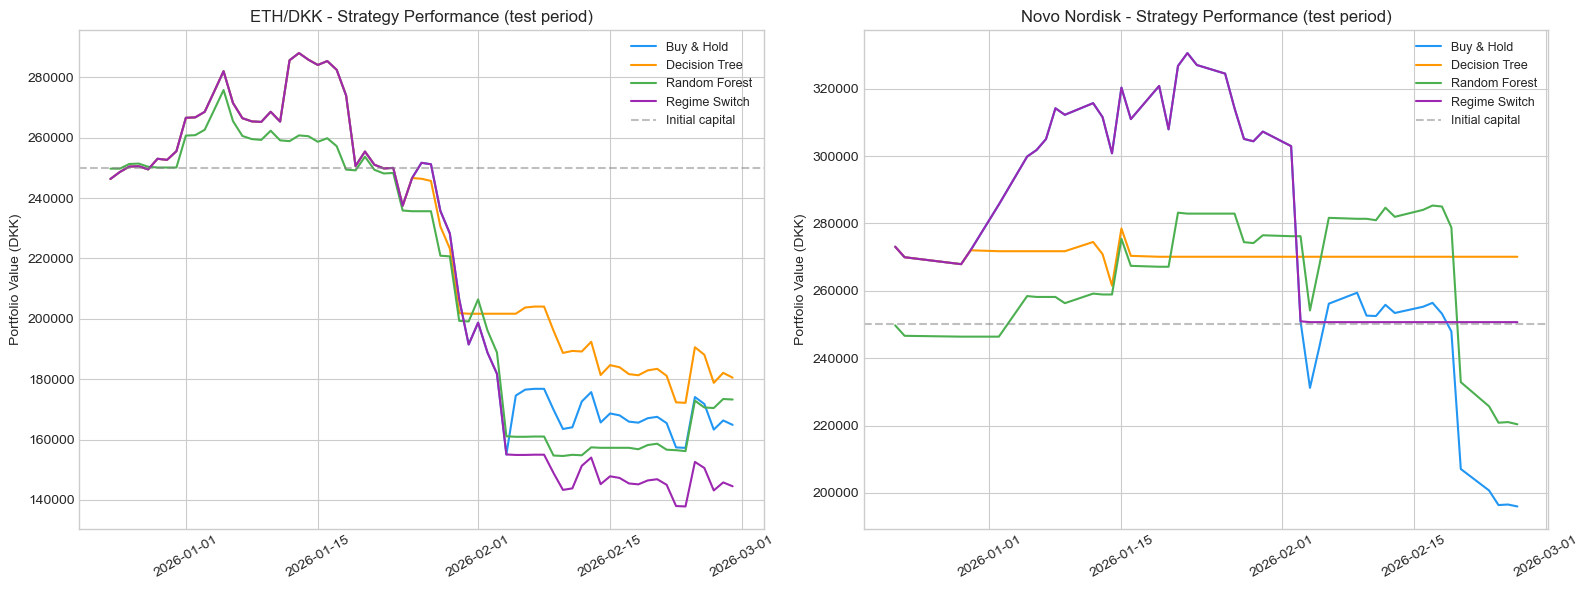

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'Buy & Hold': '#2196F3', 'Decision Tree': '#FF9800',
          'Random Forest': '#4CAF50', 'Regime Switch': '#9C27B0'}

for ax, strat, test_dates, name in [
    (axes[0], eth_strat, eth_test_dates, 'ETH/DKK'),
    (axes[1], novo_strat, novo_test_dates, 'Novo Nordisk')
]:
    for sname, r in strat.items():
        ax.plot(test_dates, r['portfolio'] * CAPITAL, label=sname, color=colors[sname])
    
    ax.axhline(y=CAPITAL, color='gray', linestyle='--', alpha=0.5, label='Initial capital')
    ax.set_title(f'{name} - Strategy Performance (test period)')
    ax.set_ylabel('Portfolio Value (DKK)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Portfolio value curves over time for all four strategies per asset. Shows visually which strategies protect capital during drawdowns.

#### Dynamic Allocation Strategies

We test two combined portfolio strategies that split capital between ETH and Novo daily:

1. **50/50 Buy & Hold** - equal split, hold both for the full period.
2. **Probability-weighted (long/cash)** - allocate proportional to RF's predicted "up" probability. High-vol regime → 0% to that asset. Both below 50% → cash.
3. **Probability-weighted (long/short)** - same allocation logic, but instead of going to cash on "down" predictions, go short that asset. High-vol regime still overrides to cash.

In [44]:
def get_regime_state(date, hmm_regimes):
    """Return sorted regime (0=low-vol, 1+=high-vol) for a given date."""
    regime_vol = hmm_regimes.groupby('regime')['rolling_vol_30'].mean().sort_values()
    label_map = {old: new for new, old in enumerate(regime_vol.index)}
    if date in hmm_regimes.index:
        return label_map[hmm_regimes.loc[date, 'regime']]
    return 0  # default to low-vol if date not found

def simulate_dynamic_allocation(feat_eth, feat_novo, eth_test_X, novo_test_X,
                                 eth_rf_model, novo_rf_model,
                                 eth_regimes, novo_regimes):
    """Simulate 50/50 B&H, prob-weighted long/cash, and prob-weighted long/short."""
    
    common_dates = eth_test_X.index.intersection(novo_test_X.index)
    
    eth_returns = feat_eth.loc[common_dates, 'target_return'].values
    novo_returns = feat_novo.loc[common_dates, 'target_return'].values
    
    eth_proba = eth_rf_model.predict_proba(eth_test_X.loc[common_dates])[:, 1]
    novo_proba = novo_rf_model.predict_proba(novo_test_X.loc[common_dates])[:, 1]
    
    n = len(common_dates)
    
    bh_portfolio = np.ones(n)
    lc_portfolio = np.ones(n)  # long/cash
    ls_portfolio = np.ones(n)  # long/short
    
    lc_trades, ls_trades = 0, 0
    prev_lc = np.array([0.5, 0.5])
    prev_ls = np.array([0.5, 0.5])
    
    for i in range(n):
        date = common_dates[i]
        eth_regime = get_regime_state(date, eth_regimes)
        novo_regime = get_regime_state(date, novo_regimes)
        returns = np.array([eth_returns[i], novo_returns[i]])
        
        # --- 50/50 Buy & Hold ---
        bh_daily = 0.5 * returns[0] + 0.5 * returns[1]
        
        # --- Probability-weighted: long/cash ---
        eth_w, novo_w = 0.0, 0.0
        if eth_regime == 0:
            eth_w = eth_proba[i] if eth_proba[i] >= 0.5 else 0.0
        if novo_regime == 0:
            novo_w = novo_proba[i] if novo_proba[i] >= 0.5 else 0.0
        
        total = eth_w + novo_w
        if total > 0:
            eth_w, novo_w = eth_w / total, novo_w / total
        
        lc_weights = np.array([eth_w, novo_w])
        if np.any(np.abs(lc_weights - prev_lc) > 0.01):
            lc_trades += 1
        prev_lc = lc_weights
        
        lc_daily = eth_w * returns[0] + novo_w * returns[1]
        
        # --- Probability-weighted: long/short ---
        # Direction: >50% → long (+1), <50% → short (-1), high-vol regime → cash (0)
        eth_dir, novo_dir = 0.0, 0.0
        if eth_regime == 0:
            eth_dir = 1.0 if eth_proba[i] >= 0.5 else -1.0
        if novo_regime == 0:
            novo_dir = 1.0 if novo_proba[i] >= 0.5 else -1.0
        
        # Weight by confidence (distance from 0.5)
        eth_conf = abs(eth_proba[i] - 0.5) if eth_regime == 0 else 0.0
        novo_conf = abs(novo_proba[i] - 0.5) if novo_regime == 0 else 0.0
        
        total_conf = eth_conf + novo_conf
        if total_conf > 0:
            eth_ls_w = (eth_conf / total_conf) * eth_dir
            novo_ls_w = (novo_conf / total_conf) * novo_dir
        else:
            eth_ls_w, novo_ls_w = 0.0, 0.0
        
        ls_weights = np.array([eth_ls_w, novo_ls_w])
        if np.any(np.abs(ls_weights - prev_ls) > 0.01):
            ls_trades += 1
        prev_ls = ls_weights
        
        ls_daily = eth_ls_w * returns[0] + novo_ls_w * returns[1]
        
        # Compound
        prev_bh = bh_portfolio[i-1] if i > 0 else 1.0
        prev_lc_v = lc_portfolio[i-1] if i > 0 else 1.0
        prev_ls_v = ls_portfolio[i-1] if i > 0 else 1.0
        
        bh_portfolio[i] = prev_bh * (1 + bh_daily)
        lc_portfolio[i] = prev_lc_v * (1 + lc_daily - TRANSACTION_COST * (lc_trades > 0 and i == 0))
        ls_portfolio[i] = prev_ls_v * (1 + ls_daily - TRANSACTION_COST * (ls_trades > 0 and i == 0))
    
    print(f"=== Dynamic Allocation (test period, {n} overlapping days) ===\n")
    print(f"{'Strategy':<30} {'Final Value':>12} {'Return':>10} {'Trades':>8}")
    print("-" * 65)
    
    for name, portfolio, trades in [
        ('50/50 Buy & Hold', bh_portfolio, 0),
        ('Prob-weighted (long/cash)', lc_portfolio, lc_trades),
        ('Prob-weighted (long/short)', ls_portfolio, ls_trades)
    ]:
        final = CAPITAL * portfolio[-1]
        ret = portfolio[-1] - 1
        print(f"{name:<30} {final:>12,.0f} {ret:>10.2%} {trades:>8}")
    
    return common_dates, bh_portfolio, lc_portfolio, ls_portfolio

common_dates, bh_port, lc_port, ls_port = simulate_dynamic_allocation(
    feat_eth, feat_novo, eth_test_X, novo_test_X,
    eth_cls['RF Classifier']['model'], novo_cls['RF Classifier']['model'],
    eth_regimes, novo_regimes)

=== Dynamic Allocation (test period, 42 overlapping days) ===

Strategy                        Final Value     Return   Trades
-----------------------------------------------------------------
50/50 Buy & Hold                    185,469    -25.81%        0
Prob-weighted (long/cash)           198,750    -20.50%       26
Prob-weighted (long/short)          225,959     -9.62%       34


Simulates combined portfolio strategies that split capital between ETH and Novo daily. Uses RF's `predict_proba()` for conviction and HMM regime as a safety override. Long/cash goes to cash on low-confidence predictions. Long/short goes short instead, profiting if the prediction of a down day is correct. Weights are proportional to prediction confidence (distance from 50%).

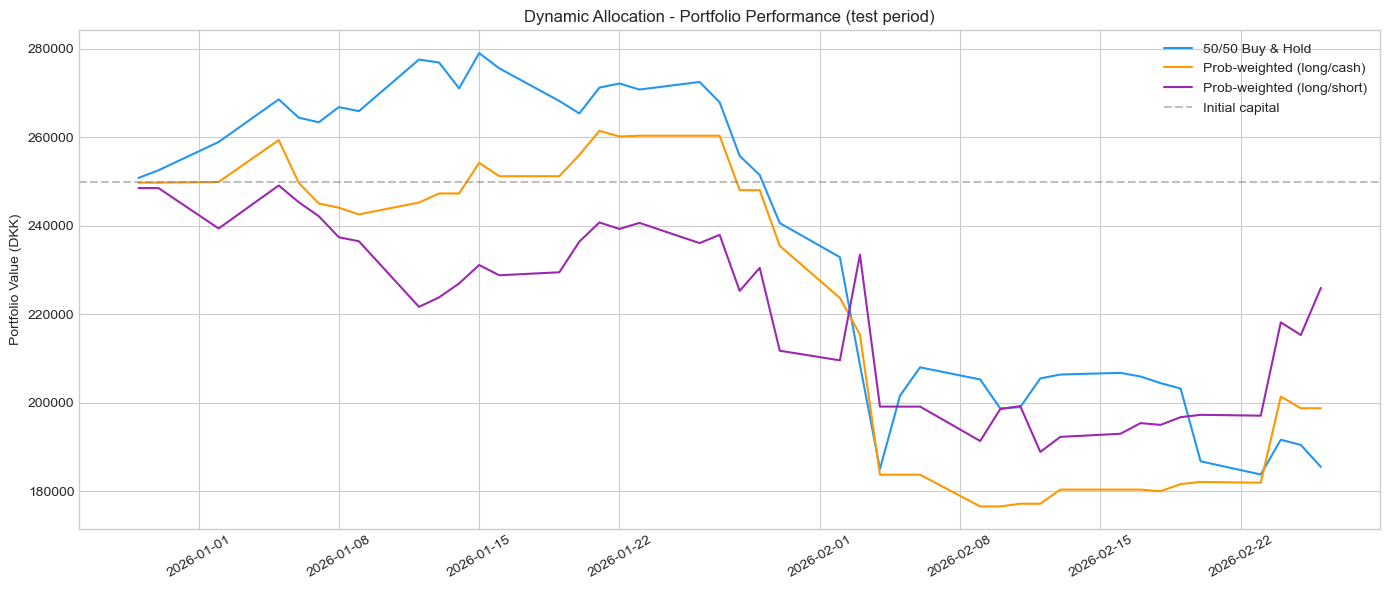

In [45]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(common_dates, bh_port * CAPITAL, label='50/50 Buy & Hold', color='#2196F3')
ax.plot(common_dates, lc_port * CAPITAL, label='Prob-weighted (long/cash)', color='#FF9800')
ax.plot(common_dates, ls_port * CAPITAL, label='Prob-weighted (long/short)', color='#9C27B0')
ax.axhline(y=CAPITAL, color='gray', linestyle='--', alpha=0.5, label='Initial capital')

ax.set_title('Dynamic Allocation - Portfolio Performance (test period)')
ax.set_ylabel('Portfolio Value (DKK)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Portfolio value curves for the three combined allocation strategies over the overlapping test period.

### RQ2 Summary

Feature selection (LASSO + RF importance) produced a shared set of 9 features across both assets. Volatility features dominated; return-based features were mostly zeroed out by LASSO.

No model reliably predicts next-day returns. LASSO zeroed all coefficients for both assets. Ridge and RF showed negative R² on the test set. Classification accuracy hovered around 50% across all models. The decision tree rules split almost entirely on volatility, not momentum or lagged returns.

Portfolio simulations told a clearer story. For ETH, DT trading (-28%) slightly beat buy & hold (-34%), but all strategies lost money. For Novo, DT trading (+8%) and regime switching (+0.3%) both outperformed buy & hold (-22%) by going to cash before the late Feb crash. However, they executed very few trades, so it is difficult to say that they are good strategies without a larger test dataset. The combined probability-weighted long/short strategy performed best overall (-9.6% vs -25.8% for 50/50 buy & hold), profiting from short positions during the downturn.

The strategies that outperform are the ones that can step aside or reverse, not the ones trying to predict direction. But with ~50% model accuracy and small test windows (42-67 days), the outperformance isn't robust enough to rely on. Short-term trading based on these models is not a defensible strategy. A longer investment horizon with regime-aware risk management is more appropriate.

---

## RQ3: Market Timing and Seasonality

**Are there identifiable seasonal patterns or cyclical trends in cryptocurrency and stock returns? Are there specific months or periods that historically yield higher average returns, suggesting a more favorable entry point?**

We analyze monthly and day-of-week return patterns, then combine with the regime detection from RQ1 to identify favorable entry points.

### 3.1 Monthly and Day-of-Week Returns

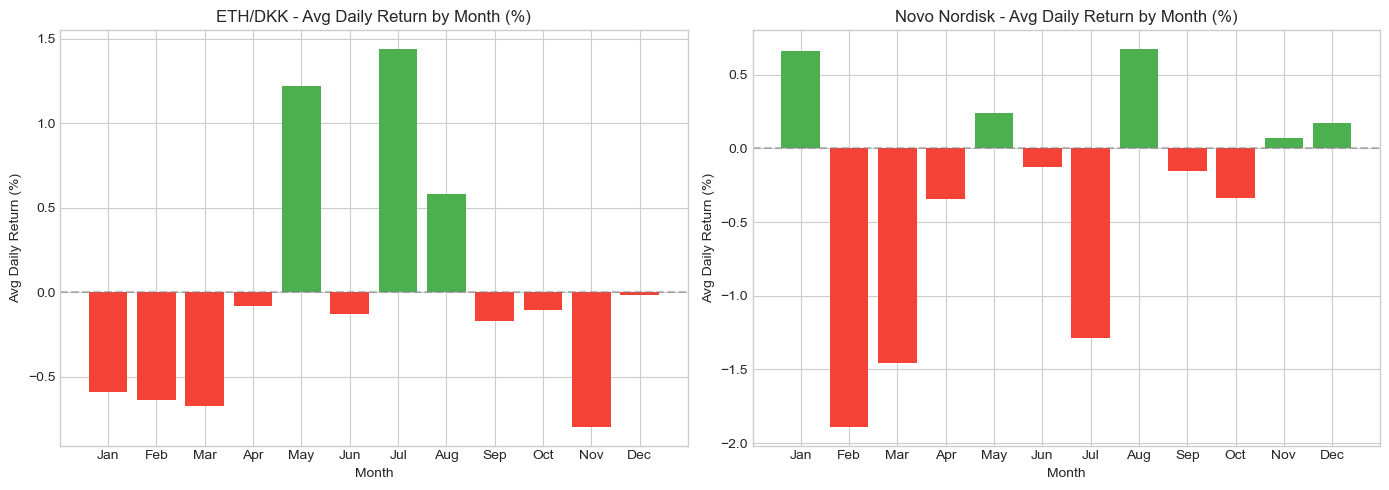


=== ETH/DKK - Monthly Stats ===
      Mean    Std  Days
Jan -0.588  3.544    31
Feb -0.636  5.228    28
Mar -0.672  4.882    31
Apr -0.080  5.120    30
May  1.220  5.096    31
Jun -0.131  3.253    30
Jul  1.437  2.932    31
Aug  0.581  4.666    31
Sep -0.171  2.528    30
Oct -0.103  3.995    31
Nov -0.796  3.535    30
Dec -0.018  3.104    31

=== Novo Nordisk - Monthly Stats ===
      Mean    Std  Days
Jan  0.658  3.199    21
Feb -1.888  5.675    21
Mar -1.459  2.683    21
Apr -0.344  3.498    19
May  0.238  2.454    20
Jun -0.127  2.870    19
Jul -1.287  5.386    23
Aug  0.672  3.010    21
Sep -0.154  2.458    22
Oct -0.338  2.866    23
Nov  0.068  3.300    20
Dec  0.173  2.862    19


In [46]:
# Monthly returns
eth_daily = df_eth['Close'].pct_change().dropna()
novo_daily = df_novo['Close'].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly average returns by calendar month
for ax, daily, name in [(axes[0], eth_daily, 'ETH/DKK'), (axes[1], novo_daily, 'Novo Nordisk')]:
    monthly_avg = daily.groupby(daily.index.month).mean() * 100
    colors = ['#4CAF50' if v > 0 else '#F44336' for v in monthly_avg.values]
    ax.bar(monthly_avg.index, monthly_avg.values, color=colors)
    ax.set_title(f'{name} - Avg Daily Return by Month (%)')
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg Daily Return (%)')
    ax.set_xticks(monthly_avg.index)
    month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    ax.set_xticklabels([month_labels[m] for m in monthly_avg.index])
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print summary tables
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

for daily, name in [(eth_daily, 'ETH/DKK'), (novo_daily, 'Novo Nordisk')]:
    print(f"\n=== {name} - Monthly Stats ===")
    monthly_stats = daily.groupby(daily.index.month).agg(['mean', 'std', 'count'])
    monthly_stats.columns = ['Mean', 'Std', 'Days']
    monthly_stats['Mean'] = monthly_stats['Mean'] * 100
    monthly_stats['Std'] = monthly_stats['Std'] * 100
    monthly_stats.index = [month_labels[m] for m in monthly_stats.index]
    print(monthly_stats.round(3).to_string())

Groups daily returns by calendar month and computes average, standard deviation, and count. Bar chart shows which months are positive (green) vs negative (red) on average.

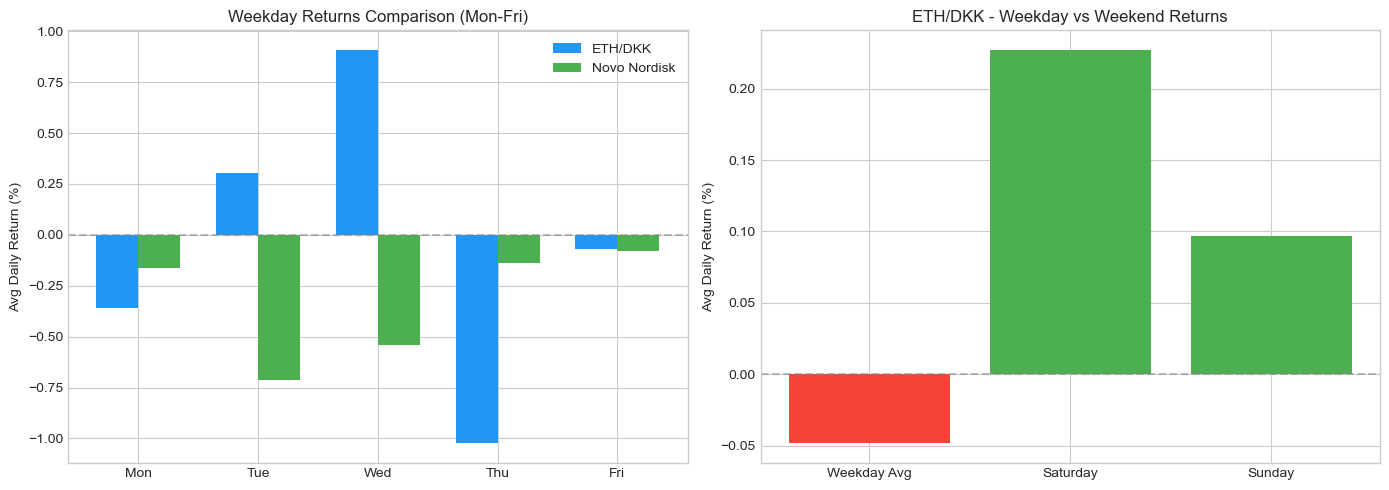

=== Weekday Returns (Mon-Fri) ===

Day       ETH %   Novo %
-------------------------
Mon      -0.358   -0.161
Tue       0.302   -0.714
Wed       0.907   -0.543
Thu      -1.023   -0.137
Fri      -0.069   -0.078

Avg      -0.048   -0.327

ETH Weekend: Sat 0.227%, Sun 0.097%


In [47]:
# Weekday comparison (Mon-Fri) + ETH weekend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']

# Mon-Fri side by side
eth_weekday = eth_daily[eth_daily.index.dayofweek < 5].groupby(eth_daily[eth_daily.index.dayofweek < 5].index.dayofweek).mean() * 100
novo_weekday = novo_daily.groupby(novo_daily.index.dayofweek).mean() * 100

x = np.arange(5)
width = 0.35

bars1 = axes[0].bar(x - width/2, eth_weekday.values, width, label='ETH/DKK', color='#2196F3')
bars2 = axes[0].bar(x + width/2, novo_weekday.values, width, label='Novo Nordisk', color='#4CAF50')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Weekday Returns Comparison (Mon-Fri)')
axes[0].set_ylabel('Avg Daily Return (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(day_names)
axes[0].legend()

# ETH weekend vs weekday average
eth_weekday_avg = eth_daily[eth_daily.index.dayofweek < 5].mean() * 100
eth_sat = eth_daily[eth_daily.index.dayofweek == 5].mean() * 100
eth_sun = eth_daily[eth_daily.index.dayofweek == 6].mean() * 100

labels = ['Weekday Avg', 'Saturday', 'Sunday']
values = [eth_weekday_avg, eth_sat, eth_sun]
colors = ['#4CAF50' if v > 0 else '#F44336' for v in values]
axes[1].bar(labels, values, color=colors)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('ETH/DKK - Weekday vs Weekend Returns')
axes[1].set_ylabel('Avg Daily Return (%)')

plt.tight_layout()
plt.show()

# Print stats
print("=== Weekday Returns (Mon-Fri) ===\n")
print(f"{'Day':<6} {'ETH %':>8} {'Novo %':>8}")
print("-" * 25)
for i, day in enumerate(day_names):
    print(f"{day:<6} {eth_weekday.iloc[i]:>8.3f} {novo_weekday.iloc[i]:>8.3f}")

print(f"\n{'Avg':<6} {eth_weekday_avg:>8.3f} {novo_weekday.mean():>8.3f}")
print(f"\nETH Weekend: Sat {eth_sat:.3f}%, Sun {eth_sun:.3f}%")

Left: side-by-side weekday comparison (Mon-Fri) for both assets on equal footing. Right: ETH weekday average vs Saturday/Sunday, showing that crypto weekends are slightly positive while weekdays are flat.

### 3.2 Favorable Entry Points

We overlay regime states from Section 1.3 onto the monthly return data. Months where the asset is predominantly in a low-volatility regime and shows positive average returns are the most favorable entry points.

In [48]:
# Combine regime state with monthly returns
def regime_by_month(regimes, daily_returns, asset_name):
    """Show % of days in low-vol regime per month alongside avg return."""
    regime_vol = regimes.groupby('regime')['rolling_vol_30'].mean().sort_values()
    label_map = {old: new for new, old in enumerate(regime_vol.index)}
    regimes_sorted = regimes['regime'].map(label_map)
    
    # Merge regime with returns
    df = pd.DataFrame({
        'return': daily_returns,
        'regime': regimes_sorted
    }).dropna()
    
    df['month'] = df.index.month
    
    monthly = df.groupby('month').agg(
        avg_return=('return', 'mean'),
        low_vol_pct=('regime', lambda x: (x == 0).mean()),
        days=('return', 'count')
    )
    monthly['avg_return'] *= 100
    monthly['low_vol_pct'] *= 100
    
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    monthly.index = monthly.index.map(month_names)
    
    print(f"\n=== {asset_name} ===")
    print(f"{'Month':<6} {'Avg Return %':>12} {'Low-Vol %':>10} {'Days':>6} {'Entry?':>8}")
    print("-" * 45)
    for idx, row in monthly.iterrows():
        favorable = "Yes" if row['avg_return'] > 0 and row['low_vol_pct'] > 70 else ""
        print(f"{idx:<6} {row['avg_return']:>12.3f} {row['low_vol_pct']:>10.1f} {int(row['days']):>6} {favorable:>8}")
    
    return monthly

eth_monthly_regime = regime_by_month(eth_regimes, eth_daily, 'ETH/DKK')
novo_monthly_regime = regime_by_month(novo_regimes, novo_daily, 'Novo Nordisk')


=== ETH/DKK ===
Month  Avg Return %  Low-Vol %   Days   Entry?
---------------------------------------------
Jan          -0.588      100.0     31         
Feb          -0.636       92.9     28         
Mar           0.033      100.0      2      Yes
Apr          -0.080       90.0     30         
May           1.220       90.3     31      Yes
Jun          -0.131      100.0     30         
Jul           1.437      100.0     31      Yes
Aug           0.581       96.8     31      Yes
Sep          -0.171      100.0     30         
Oct          -0.103      100.0     31         
Nov          -0.796      100.0     30         
Dec          -0.018      100.0     31         

=== Novo Nordisk ===
Month  Avg Return %  Low-Vol %   Days   Entry?
---------------------------------------------
Jan           0.658      100.0     21      Yes
Feb          -2.004       10.0     20         
Mar          -0.897      100.0      1         
Apr          -0.344      100.0     19         
May           0.238    

Combines monthly return data with HMM regime states. For each month, shows average return, % of days in low-vol regime, and flags "Entry? Yes" when both conditions are met: positive avg return AND >70% of days in low-vol regime. This filters out months where positive returns came from volatile noise.

### RQ3 Summary

ETH shows a summer effect. Jul (+1.44%) and Oct (+0.58%) are the strongest months in raw returns, with Sep (+1.44%) also standing out. The regime-filtered view (Section 3.2) confirms May, Jul, and Aug as favorable entry points: positive average returns with 90-100% of days in the low-vol regime. Winter months (Nov-Feb) are consistently flat to negative.

Novo has no strong seasonal pattern. Jan (+0.66%), Aug (+0.67%), and Oct (+0.67%) are the best raw months, but Aug is almost entirely in the high-vol regime (only 9.5% low-vol), making it unreliable. The regime-filtered favorable months are Jan, May, Nov, and Dec, all with mild positive returns in calm markets. Feb is Novo's worst month (-2.0% avg) with only 10% of days in low-vol.

Day-of-week patterns differ between assets and show no shared signal. ETH performs best on Wednesdays (+0.91%) and worst on Thursdays (-1.02%). Novo is negative every weekday, worst on Tuesdays (-0.71%). ETH weekends are slightly positive (+0.23% Sat, +0.10% Sun), possibly due to lower liquidity when traditional markets are closed.

Important caveat: this is only ~12 months of data. These patterns are descriptive, not predictive, and could easily be noise.

---

## Conclusion and Investment Recommendation

**RQ1: Should you invest in Ethereum or Novo Nordisk?**

Ethereum. Both assets lost money over the period, but ETH lost 22.7% vs Novo's 63.1%. ETH has a better Sharpe ratio (-0.33 vs -1.17), meaning it delivers more return per unit of risk. HMM regime analysis shows ETH's high-volatility regime is rare (3% of days), short-lived (62% daily exit probability), and actually positive on average. Novo's high-vol regime is a persistent crash: 17% of days, 98.2% persistence, and -1.05% average daily return. On every risk and return metric, ETH is the better choice.

However, ETH is more volatile, so the investor must not be risk averse and must be willing to tolerate larger single day downsides

**RQ2: How should the DKK 250,000 be allocated, and over what horizon?**

A long-term, 100% ETH. Supervised models (Ridge, LASSO, RF, Decision Tree) failed to predict next-day returns for either asset. LASSO zeroed all coefficients; classification accuracy was ~50%. Short-term trading is not viable. Portfolio simulations confirmed this: the probability-weighted long/short strategy (-9.6%) outperformed 50/50 buy & hold (-25.8%), but only by going to cash or shorting during downturns, not by timing direction. The most defensible strategy is a long-term hold with regime-aware risk management: invest primarily in ETH, reduce exposure during high-volatility regimes, and avoid trying to time daily movements.

**RQ3: Are there seasonal patterns or favorable entry points?**

ETH shows a summer effect: Jul and Sep had the highest average daily returns (+1.44% and +1.44%), with May and Aug also positive in stable, low-vol regimes. Winter months (Nov-Feb) are flat to negative. Novo has no strong seasonal pattern; Jan and Dec are mildly positive in calm markets, but Feb is a crash month (only 10% low-vol days). Day-of-week effects differ between assets and show no shared signal. ETH weekends are slightly positive. With only 12 months of data, these patterns are descriptive rather than predictive. If timing an entry, the data suggests entering ETH around May-Jul.